In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
import pandas as pd
import statistics
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings('ignore')

# load 4 dataset

In [ ]:
#micro loan
df1=pd.read_csv('/content/drive/MyDrive/Capstone-Thesis/Datasets/kiva_small_loans/kiva_loans.csv')
print(df1.shape) #shows num of row and column
df1.head(3)

(671205, 20)


,id,funded_amount,loan_amount,activity,sector,use,country_code,country,region,currency,partner_id,posted_time,disbursed_time,funded_time,term_in_months,lender_count,tags,borrower_genders,repayment_interval,date
0,653051,300.0,300.0,Fruits & Vegetables,Food,"To buy seasonal, fresh fruits to sell.",PK,Pakistan,Lahore,PKR,247.0,2014-01-01 06:12:39+00:00,2013-12-17 08:00:00+00:00,2014-01-02 10:06:32+00:00,12.0,12,NaN,female,irregular,2014-01-01
1,653053,575.0,575.0,Rickshaw,Transportation,to repair and maintain the auto rickshaw used ...,PK,Pakistan,Lahore,PKR,247.0,2014-01-01 06:51:08+00:00,2013-12-17 08:00:00+00:00,2014-01-02 09:17:23+00:00,11.0,14,NaN,"female, female",irregular,2014-01-01
2,653068,150.0,150.0,Transportation,Transportation,To repair their old cycle-van and buy another ...,IN,India,Maynaguri,INR,334.0,2014-01-01 09:58:07+00:00,2013-12-17 08:00:00+00:00,2014-01-01 16:01:36+00:00,43.0,6,"user_favorite, user_favorite",female,bullet,2014-01-01


In [ ]:
#country profile
df2=pd.read_csv('/content/drive/MyDrive/Capstone-Thesis/Datasets/kiva_small_loans/kiva_country_profile_variables.csv')
print(df2.shape) #shows num of row and column
df2.head(3)

(86, 50)


,country,Region,Surface area (km2),Population in thousands (2017),"Population density (per km2, 2017)","Sex ratio (m per 100 f, 2017)",GDP: Gross domestic product (million current US$),"GDP growth rate (annual %, const. 2005 prices)",GDP per capita (current US$),Economy: Agriculture (% of GVA),...,Mobile-cellular subscriptions (per 100 inhabitants).1,Individuals using the Internet (per 100 inhabitants),Threatened species (number),Forested area (% of land area),CO2 emission estimates (million tons/tons per capita),"Energy production, primary (Petajoules)",Energy supply per capita (Gigajoules),"Pop. using improved drinking water (urban/rural, %)","Pop. using improved sanitation facilities (urban/rural, %)",Net Official Development Assist. received (% of GNI)
0,Afghanistan,SouthernAsia,652864,35530,54.4,106.3,20270,-2.4,623.2,23.3,...,8.3,42,2.1,9.8/0.3,63,5,78.2/47.0,45.1/27.0,21.43,-99
1,Albania,SouthernEurope,28748,2930,106.9,101.9,11541,2.6,3984.2,22.4,...,63.3,130,28.2,5.7/2.0,84,36,94.9/95.2,95.5/90.2,2.96,-99
2,Armenia,WesternAsia,29743,2930,102.9,88.8,10529,3.0,3489.1,19.0,...,58.2,114,11.7,5.5/1.8,48,46,100.0/100.0,96.2/78.2,3.17,-99


In [ ]:
#loan theme by id
df3=pd.read_csv('/content/drive/MyDrive/Capstone-Thesis/Datasets/kiva_small_loans/loan_theme_ids.csv')
print(df3.shape) #shows num of row and column
df3.head(3)

(779092, 4)


,id,Loan Theme ID,Loan Theme Type,Partner ID
0,638631,a1050000000skGl,General,151.0
1,640322,a1050000000skGl,General,151.0
2,641006,a1050000002X1ij,Higher Education,160.0


In [ ]:
#region poverty 2
df4=pd.read_csv('/content/drive/MyDrive/Capstone-Thesis/Datasets/kiva_small_loans/kiva_mpi_region_locations.csv')
print(df4.shape) #shows num of row and column
df4.head(3)

(1008, 9)


,LocationName,ISO,country,region,world_region,MPI,geo,lat,lon
0,"Badakhshan, Afghanistan",AFG,Afghanistan,Badakhshan,South Asia,0.387,"(36.7347725, 70.81199529999999)",36.734772,70.811995
1,"Badghis, Afghanistan",AFG,Afghanistan,Badghis,South Asia,0.466,"(35.1671339, 63.7695384)",35.167134,63.769538
2,"Baghlan, Afghanistan",AFG,Afghanistan,Baghlan,South Asia,0.300,"(35.8042947, 69.2877535)",35.804295,69.287753


# merge df1 and df2

In [ ]:
# Merge df1 and df2 based on the 'country' column
merge1 = pd.merge(df1, df2, on='country', how='left')

print(merge1.shape)
merge1.head(5)


(671205, 69)


,id,funded_amount,loan_amount,activity,sector,use,country_code,country,region,currency,...,Mobile-cellular subscriptions (per 100 inhabitants).1,Individuals using the Internet (per 100 inhabitants),Threatened species (number),Forested area (% of land area),CO2 emission estimates (million tons/tons per capita),"Energy production, primary (Petajoules)",Energy supply per capita (Gigajoules),"Pop. using improved drinking water (urban/rural, %)","Pop. using improved sanitation facilities (urban/rural, %)",Net Official Development Assist. received (% of GNI)
0,653051,300.0,300.0,Fruits & Vegetables,Food,"To buy seasonal, fresh fruits to sell.",PK,Pakistan,Lahore,PKR,...,18.0,140.0,2.0,166.3/0.9,2202.0,17.0,93.9/89.9,83.1/51.1,1.32,-99.0
1,653053,575.0,575.0,Rickshaw,Transportation,to repair and maintain the auto rickshaw used ...,PK,Pakistan,Lahore,PKR,...,18.0,140.0,2.0,166.3/0.9,2202.0,17.0,93.9/89.9,83.1/51.1,1.32,-99.0
2,653068,150.0,150.0,Transportation,Transportation,To repair their old cycle-van and buy another ...,IN,India,Maynaguri,INR,...,26.0,1052.0,23.7,2238.4/1.7,23103.0,27.0,97.1/92.6,62.6/28.5,0.16,-99.0
3,653063,200.0,200.0,Embroidery,Arts,to purchase an embroidery machine and a variet...,PK,Pakistan,Lahore,PKR,...,18.0,140.0,2.0,166.3/0.9,2202.0,17.0,93.9/89.9,83.1/51.1,1.32,-99.0
4,653084,400.0,400.0,Milk Sales,Food,to purchase one buffalo.,PK,Pakistan,Abdul Hakeem,PKR,...,18.0,140.0,2.0,166.3/0.9,2202.0,17.0,93.9/89.9,83.1/51.1,1.32,-99.0


In [ ]:
print(merge1.shape, "\n\n")
merge1.info()


(671205, 69) 


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 671205 entries, 0 to 671204
Data columns (total 69 columns):
 #   Column                                                      Non-Null Count   Dtype  
---  ------                                                      --------------   -----  
 0   id                                                          671205 non-null  int64  
 1   funded_amount                                               671205 non-null  float64
 2   loan_amount                                                 671205 non-null  float64
 3   activity                                                    671205 non-null  object 
 4   sector                                                      671205 non-null  object 
 5   use                                                         666973 non-null  object 
 6   country_code                                                671197 non-null  object 
 7   country                                                   

# merge df3

In [ ]:
# Merge merge1 and df3 based on the 'id' column
merge2 = pd.merge(merge1, df3, on='id', how='left')

print(merge2.shape)
merge2.head(5)


(671205, 72)


,id,funded_amount,loan_amount,activity,sector,use,country_code,country,region,currency,...,Forested area (% of land area),CO2 emission estimates (million tons/tons per capita),"Energy production, primary (Petajoules)",Energy supply per capita (Gigajoules),"Pop. using improved drinking water (urban/rural, %)","Pop. using improved sanitation facilities (urban/rural, %)",Net Official Development Assist. received (% of GNI),Loan Theme ID,Loan Theme Type,Partner ID
0,653051,300.0,300.0,Fruits & Vegetables,Food,"To buy seasonal, fresh fruits to sell.",PK,Pakistan,Lahore,PKR,...,166.3/0.9,2202.0,17.0,93.9/89.9,83.1/51.1,1.32,-99.0,NaN,NaN,NaN
1,653053,575.0,575.0,Rickshaw,Transportation,to repair and maintain the auto rickshaw used ...,PK,Pakistan,Lahore,PKR,...,166.3/0.9,2202.0,17.0,93.9/89.9,83.1/51.1,1.32,-99.0,a1050000000sjEC,Underserved,247.0
2,653068,150.0,150.0,Transportation,Transportation,To repair their old cycle-van and buy another ...,IN,India,Maynaguri,INR,...,2238.4/1.7,23103.0,27.0,97.1/92.6,62.6/28.5,0.16,-99.0,a1050000002VkWz,Underserved,334.0
3,653063,200.0,200.0,Embroidery,Arts,to purchase an embroidery machine and a variet...,PK,Pakistan,Lahore,PKR,...,166.3/0.9,2202.0,17.0,93.9/89.9,83.1/51.1,1.32,-99.0,a1050000000sjEC,Underserved,247.0
4,653084,400.0,400.0,Milk Sales,Food,to purchase one buffalo.,PK,Pakistan,Abdul Hakeem,PKR,...,166.3/0.9,2202.0,17.0,93.9/89.9,83.1/51.1,1.32,-99.0,a1050000000wf22,General,245.0


In [ ]:
merge2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 671205 entries, 0 to 671204
Data columns (total 72 columns):
 #   Column                                                      Non-Null Count   Dtype  
---  ------                                                      --------------   -----  
 0   id                                                          671205 non-null  int64  
 1   funded_amount                                               671205 non-null  float64
 2   loan_amount                                                 671205 non-null  float64
 3   activity                                                    671205 non-null  object 
 4   sector                                                      671205 non-null  object 
 5   use                                                         666973 non-null  object 
 6   country_code                                                671197 non-null  object 
 7   country                                                     671205 non-nul

In [ ]:
merge2.describe(include='all')

,id,funded_amount,loan_amount,activity,sector,use,country_code,country,region,currency,...,Forested area (% of land area),CO2 emission estimates (million tons/tons per capita),"Energy production, primary (Petajoules)",Energy supply per capita (Gigajoules),"Pop. using improved drinking water (urban/rural, %)","Pop. using improved sanitation facilities (urban/rural, %)",Net Official Development Assist. received (% of GNI),Loan Theme ID,Loan Theme Type,Partner ID
count,6.712050e+05,671205.000000,671205.000000,671205,671205,666973,671197,671205,614405,671205,...,669786,669786.000000,669786.000000,669786,669786,669786.000000,669786.0,657692,657692,657692.000000
unique,NaN,NaN,NaN,163,15,424912,86,87,12695,67,...,84,NaN,NaN,81,85,NaN,NaN,912,197,NaN
top,NaN,NaN,NaN,Farming,Agriculture,to buy a water filter to provide safe drinking...,PH,Philippines,Kaduna,PHP,...,105.7/1.1,NaN,NaN,93.7/90.3,77.9/70.8,NaN,NaN,a1050000000wf0q,General,NaN
freq,NaN,NaN,NaN,72955,180302,5217,160441,160441,10000,160440,...,160441,NaN,NaN,160441,160441,NaN,NaN,95900,337812,NaN
mean,9.932486e+05,785.995061,842.397107,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,2420.506141,26.061408,NaN,NaN,2.281379,-99.0,NaN,NaN,178.204267
std,1.966113e+05,1130.398941,1198.660073,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,8775.593125,27.621795,NaN,NaN,11.517726,0.0,NaN,NaN,94.250826
min,6.530470e+05,0.000000,25.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,-99.000000,-99.000000,NaN,NaN,-99.000000,-99.0,NaN,NaN,9.000000
25%,8.230720e+05,250.000000,275.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,129.000000,19.000000,NaN,NaN,0.150000,-99.0,NaN,NaN,126.000000
50%,9.927800e+05,450.000000,500.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,750.000000,20.000000,NaN,NaN,1.320000,-99.0,NaN,NaN,145.000000
75%,1.163653e+06,900.000000,1000.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,991.000000,28.000000,NaN,NaN,3.970000,-99.0,NaN,NaN,204.000000


# merge df4 only the MPI

In [ ]:
# Merge merge2 and df4 based on 'country' and 'region' columns, selecting only the 'MPI' column from df4
merge3 = pd.merge(merge2, df4[['country', 'region', 'MPI']], on=['country', 'region'], how='left')

print(merge3.shape)
merge3.head(5)


(671205, 73)


,id,funded_amount,loan_amount,activity,sector,use,country_code,country,region,currency,...,CO2 emission estimates (million tons/tons per capita),"Energy production, primary (Petajoules)",Energy supply per capita (Gigajoules),"Pop. using improved drinking water (urban/rural, %)","Pop. using improved sanitation facilities (urban/rural, %)",Net Official Development Assist. received (% of GNI),Loan Theme ID,Loan Theme Type,Partner ID,MPI
0,653051,300.0,300.0,Fruits & Vegetables,Food,"To buy seasonal, fresh fruits to sell.",PK,Pakistan,Lahore,PKR,...,2202.0,17.0,93.9/89.9,83.1/51.1,1.32,-99.0,NaN,NaN,NaN,NaN
1,653053,575.0,575.0,Rickshaw,Transportation,to repair and maintain the auto rickshaw used ...,PK,Pakistan,Lahore,PKR,...,2202.0,17.0,93.9/89.9,83.1/51.1,1.32,-99.0,a1050000000sjEC,Underserved,247.0,NaN
2,653068,150.0,150.0,Transportation,Transportation,To repair their old cycle-van and buy another ...,IN,India,Maynaguri,INR,...,23103.0,27.0,97.1/92.6,62.6/28.5,0.16,-99.0,a1050000002VkWz,Underserved,334.0,NaN
3,653063,200.0,200.0,Embroidery,Arts,to purchase an embroidery machine and a variet...,PK,Pakistan,Lahore,PKR,...,2202.0,17.0,93.9/89.9,83.1/51.1,1.32,-99.0,a1050000000sjEC,Underserved,247.0,NaN
4,653084,400.0,400.0,Milk Sales,Food,to purchase one buffalo.,PK,Pakistan,Abdul Hakeem,PKR,...,2202.0,17.0,93.9/89.9,83.1/51.1,1.32,-99.0,a1050000000wf22,General,245.0,NaN


In [ ]:
merge3.describe(include='all')

,id,funded_amount,loan_amount,activity,sector,use,country_code,country,region,currency,...,CO2 emission estimates (million tons/tons per capita),"Energy production, primary (Petajoules)",Energy supply per capita (Gigajoules),"Pop. using improved drinking water (urban/rural, %)","Pop. using improved sanitation facilities (urban/rural, %)",Net Official Development Assist. received (% of GNI),Loan Theme ID,Loan Theme Type,Partner ID,MPI
count,6.712050e+05,671205.000000,671205.000000,671205,671205,666973,671197,671205,614405,671205,...,669786.000000,669786.000000,669786,669786,669786.000000,669786.0,657692,657692,657692.000000,50955.000000
unique,NaN,NaN,NaN,163,15,424912,86,87,12695,67,...,NaN,NaN,81,85,NaN,NaN,912,197,NaN,NaN
top,NaN,NaN,NaN,Farming,Agriculture,to buy a water filter to provide safe drinking...,PH,Philippines,Kaduna,PHP,...,NaN,NaN,93.7/90.3,77.9/70.8,NaN,NaN,a1050000000wf0q,General,NaN,NaN
freq,NaN,NaN,NaN,72955,180302,5217,160441,160441,10000,160440,...,NaN,NaN,160441,160441,NaN,NaN,95900,337812,NaN,NaN
mean,9.932486e+05,785.995061,842.397107,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2420.506141,26.061408,NaN,NaN,2.281379,-99.0,NaN,NaN,178.204267,0.136743
std,1.966113e+05,1130.398941,1198.660073,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,8775.593125,27.621795,NaN,NaN,11.517726,0.0,NaN,NaN,94.250826,0.120174
min,6.530470e+05,0.000000,25.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-99.000000,-99.000000,NaN,NaN,-99.000000,-99.0,NaN,NaN,9.000000,0.000000
25%,8.230720e+05,250.000000,275.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,129.000000,19.000000,NaN,NaN,0.150000,-99.0,NaN,NaN,126.000000,0.031000
50%,9.927800e+05,450.000000,500.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,750.000000,20.000000,NaN,NaN,1.320000,-99.0,NaN,NaN,145.000000,0.090000
75%,1.163653e+06,900.000000,1000.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,991.000000,28.000000,NaN,NaN,3.970000,-99.0,NaN,NaN,204.000000,0.211000


In [ ]:
merge3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 671205 entries, 0 to 671204
Data columns (total 73 columns):
 #   Column                                                      Non-Null Count   Dtype  
---  ------                                                      --------------   -----  
 0   id                                                          671205 non-null  int64  
 1   funded_amount                                               671205 non-null  float64
 2   loan_amount                                                 671205 non-null  float64
 3   activity                                                    671205 non-null  object 
 4   sector                                                      671205 non-null  object 
 5   use                                                         666973 non-null  object 
 6   country_code                                                671197 non-null  object 
 7   country                                                     671205 non-nul

In [ ]:
# Download only the first 1000 rows of the new dataset
"""
from google.colab import files
merge3.head(1000).to_csv('m3.csv', encoding='utf-8-sig', index=False)  # Set index=False to avoid saving row indices
files.download('m3.csv')
"""


"\nfrom google.colab import files\nmerge3.head(1000).to_csv('m3.csv', encoding='utf-8-sig', index=False)  # Set index=False to avoid saving row indices\nfiles.download('m3.csv')\n"

# Cleaning useless columns

In [ ]:
# List of columns to remove
useless_columns = [
    # Identification & Redundant Columns
    'Loan Theme ID','Partner ID', 'country_code', 'currency', 'posted_time',
    'disbursed_time', 'funded_time', 'date',
    # Geographic & Environmental Data
    'Surface area (km2)', 'Population in thousands (2017)', 'Population density (per km2, 2017)',
    'Sex ratio (m per 100 f, 2017)', 'Threatened species (number)', 'Forested area (% of land area)',
    'CO2 emission estimates (million tons/tons per capita)', 'Energy production, primary (Petajoules)',
    'Energy supply per capita (Gigajoules)',
    # Macroeconomic Data
    'International trade: Exports (million US$)', 'International trade: Imports (million US$)',
    'International trade: Balance (million US$)', 'Balance of payments, current account (million US$)',
    # Social & Health Indicators
    'Labour force participation (female/male pop. %)', 'Fertility rate, total (live births per woman)',
    'Life expectancy at birth (females/males, years)', 'Population age distribution (0-14 / 60+ years, %)',
    'International migrant stock (000/% of total pop.)', 'Refugees and others of concern to UNHCR (in thousands)',
    'Infant mortality rate (per 1000 live births)', 'Health: Total expenditure (% of GDP)',
    'Health: Physicians (per 1000 pop.)', 'Infant mortality rate (per 1000 live births',
    # Education Data
    'Education: Government expenditure (% of GDP)', 'Education: Primary gross enrol. ratio (f/m per 100 pop.)',
    'Education: Secondary gross enrol. ratio (f/m per 100 pop.)', 'Education: Tertiary gross enrol. ratio (f/m per 100 pop.)',
    # Infrastructure & Miscellaneous
    'Seats held by women in national parliaments %', 'Mobile-cellular subscriptions (per 100 inhabitants).1',
    'Pop. using improved drinking water (urban/rural, %)', 'Pop. using improved sanitation facilities (urban/rural, %)',
    'Net Official Development Assist. received (% of GNI)',
    # High Missing Values
    'tags'
]

# Drop the columns
final_df = merge3.drop(columns=useless_columns, errors='ignore')
# Display the first few rows of the updated dataset
final_df.head(5)
final_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 671205 entries, 0 to 671204
Data columns (total 33 columns):
 #   Column                                                Non-Null Count   Dtype  
---  ------                                                --------------   -----  
 0   id                                                    671205 non-null  int64  
 1   funded_amount                                         671205 non-null  float64
 2   loan_amount                                           671205 non-null  float64
 3   activity                                              671205 non-null  object 
 4   sector                                                671205 non-null  object 
 5   use                                                   666973 non-null  object 
 6   country                                               671205 non-null  object 
 7   region                                                614405 non-null  object 
 8   partner_id                                  

In [ ]:
final_df.describe(include='all')

,id,funded_amount,loan_amount,activity,sector,use,country,region,partner_id,term_in_months,...,Unemployment (% of labour force),Agricultural production index (2004-2006=100),Food production index (2004-2006=100),Population growth rate (average annual %),Urban population (% of total population),Urban population growth rate (average annual %),Mobile-cellular subscriptions (per 100 inhabitants),Individuals using the Internet (per 100 inhabitants),Loan Theme Type,MPI
count,6.712050e+05,671205.000000,671205.000000,671205,671205,666973,671205,614405,657698.000000,671205.000000,...,669786,669786.000000,669786.000000,669786,669786.000000,669786.000000,669786,669786.000000,657692,50955.000000
unique,NaN,NaN,NaN,163,15,424912,87,12695,NaN,NaN,...,66,NaN,NaN,36,NaN,NaN,83,NaN,197,NaN
top,NaN,NaN,NaN,Farming,Agriculture,to buy a water filter to provide safe drinking...,Philippines,Kaduna,NaN,NaN,...,5.9,NaN,NaN,1.6,NaN,NaN,118.1,NaN,General,NaN
freq,NaN,NaN,NaN,72955,180302,5217,160441,10000,NaN,NaN,...,191862,NaN,NaN,225273,NaN,NaN,160441,NaN,337812,NaN
mean,9.932486e+05,785.995061,842.397107,NaN,NaN,NaN,NaN,NaN,178.199616,13.739022,...,NaN,128.739918,129.803893,NaN,45.570162,2.531210,NaN,495.845334,NaN,0.136743
std,1.966113e+05,1130.398941,1198.660073,NaN,NaN,NaN,NaN,NaN,94.247581,8.598919,...,NaN,20.071144,21.489453,NaN,18.504266,1.389424,NaN,433.024767,NaN,0.120174
min,6.530470e+05,0.000000,25.000000,NaN,NaN,NaN,NaN,NaN,9.000000,1.000000,...,NaN,-99.000000,-99.000000,NaN,12.100000,-0.700000,NaN,18.000000,NaN,0.000000
25%,8.230720e+05,250.000000,275.000000,NaN,NaN,NaN,NaN,NaN,126.000000,8.000000,...,NaN,120.000000,120.000000,NaN,28.800000,1.300000,NaN,140.000000,NaN,0.031000
50%,9.927800e+05,450.000000,500.000000,NaN,NaN,NaN,NaN,NaN,145.000000,13.000000,...,NaN,122.000000,121.000000,NaN,44.400000,2.300000,NaN,480.000000,NaN,0.090000
75%,1.163653e+06,900.000000,1000.000000,NaN,NaN,NaN,NaN,NaN,204.000000,14.000000,...,NaN,139.000000,139.000000,NaN,59.700000,3.400000,NaN,783.000000,NaN,0.211000


In [ ]:
final_df.nunique()

,0
id,671205
funded_amount,610
loan_amount,479
activity,163
sector,15
use,424912
country,87
region,12695
partner_id,366
term_in_months,148


In [ ]:
final_df.describe()

,id,funded_amount,loan_amount,partner_id,term_in_months,lender_count,GDP: Gross domestic product (million current US$),GDP per capita (current US$),Economy: Agriculture (% of GVA),Economy: Industry (% of GVA),Economy: Services and other activity (% of GVA),Employment: Agriculture (% of employed),Employment: Industry (% of employed),Employment: Services (% of employed),Agricultural production index (2004-2006=100),Food production index (2004-2006=100),Urban population (% of total population),Urban population growth rate (average annual %),Individuals using the Internet (per 100 inhabitants),MPI
count,6.712050e+05,671205.000000,671205.000000,657698.000000,671205.000000,671205.000000,6.697860e+05,669786.000000,669786.000000,669786.000000,669786.000000,669786.000000,669786.000000,669786.000000,669786.000000,669786.000000,669786.000000,669786.000000,669786.000000,50955.000000
mean,9.932486e+05,785.995061,842.397107,178.199616,13.739022,20.590922,3.493058e+05,3253.273179,17.993442,27.451429,54.559651,37.043390,15.780361,47.099947,128.739918,129.803893,45.570162,2.531210,495.845334,0.136743
std,1.966113e+05,1130.398941,1198.660073,94.247581,8.598919,28.459551,1.729494e+06,5433.056405,10.858355,7.090377,8.841851,18.874974,5.487563,15.511548,20.071144,21.489453,18.504266,1.389424,433.024767,0.120174
min,6.530470e+05,0.000000,25.000000,9.000000,1.000000,0.000000,-9.900000e+01,-99.000000,-99.000000,-99.000000,-99.000000,-99.000000,-99.000000,-99.000000,-99.000000,-99.000000,12.100000,-0.700000,18.000000,0.000000
25%,8.230720e+05,250.000000,275.000000,126.000000,8.000000,7.000000,2.528200e+04,1376.700000,10.500000,21.200000,49.000000,25.700000,13.400000,29.500000,120.000000,120.000000,28.800000,1.300000,140.000000,0.031000
50%,9.927800e+05,450.000000,500.000000,145.000000,13.000000,13.000000,6.339900e+04,2904.200000,13.000000,28.300000,56.500000,27.900000,16.300000,55.100000,122.000000,121.000000,44.400000,2.300000,480.000000,0.090000
75%,1.163653e+06,900.000000,1000.000000,204.000000,14.000000,24.000000,2.924490e+05,3489.100000,25.600000,31.300000,58.700000,56.700000,19.600000,56.100000,139.000000,139.000000,59.700000,3.400000,783.000000,0.211000
max,1.340339e+06,100000.000000,100000.000000,536.000000,158.000000,2986.000000,1.803665e+07,56053.800000,70.800000,79.900000,79.300000,91.100000,30.900000,85.700000,193.000000,186.000000,95.300000,6.400000,2358.000000,0.522000


In [ ]:
final_df.isnull().sum()

,0
id,0
funded_amount,0
loan_amount,0
activity,0
sector,0
use,4232
country,0
region,56800
partner_id,13507
term_in_months,0


# download

In [ ]:
"""
from google.colab import files
final_df.to_csv('final_merged_dataset.csv', encoding = 'utf-8-sig')
files.download('final_merged_dataset.csv')
"""

"\nfrom google.colab import files\nfinal_df.to_csv('final_merged_dataset.csv', encoding = 'utf-8-sig')\nfiles.download('final_merged_dataset.csv')\n"

# Data Preprocessing

**Columns for Credit Score Calculation:**

1. funded_amount
2. loan_amount
3. term_in_months
4. lender_count
5. activity
6. sector
7. use
8. Loan Theme Type
9. partner_id
10. borrower_genders
11. GDP per capita (current US$)
12. Employment: Services (% of employed)
13. Employment: Industry (% of employed)
14. Urban population (% of total population)

**Columns for Risk Score Calculation:**

1. funded_amount
2. loan_amount
3. term_in_months
4. repayment_interval
5. country
6. region
7. Unemployment (% of labour force)
8. Population growth rate (average annual %)
9. GDP growth rate (annual %, const. 2005 prices)
10. Economy: Agriculture (% of GVA)
11. Balance of payments, current account (million US$)

In [ ]:
# Identify categorical and numerical columns
categorical_cols = final_df.select_dtypes(include=['object', 'category']).columns
numerical_cols = final_df.select_dtypes(include=['number']).columns

print("Categorical Columns:", categorical_cols)
print("\nNumerical Columns:", numerical_cols)


Categorical Columns: Index(['activity', 'sector', 'use', 'country', 'region', 'borrower_genders',
       'repayment_interval', 'Region',
       'GDP growth rate (annual %, const. 2005 prices)',
       'Unemployment (% of labour force)',
       'Population growth rate (average annual %)',
       'Mobile-cellular subscriptions (per 100 inhabitants)',
       'Loan Theme Type'],
      dtype='object')

Numerical Columns: Index(['id', 'funded_amount', 'loan_amount', 'partner_id', 'term_in_months',
       'lender_count', 'GDP: Gross domestic product (million current US$)',
       'GDP per capita (current US$)', 'Economy: Agriculture (% of GVA)',
       'Economy: Industry (% of GVA)',
       'Economy: Services and other activity (% of GVA)',
       'Employment: Agriculture (% of employed)',
       'Employment: Industry (% of employed)',
       'Employment: Services (% of employed)',
       'Agricultural production index (2004-2006=100)',
       'Food production index (2004-2006=100)',
       '

In [ ]:
# Check for duplicates in the entire DataFrame
duplicates = final_df[final_df.duplicated()]

# Print the number of duplicate rows
print(f"Number of duplicate rows: {len(duplicates)}")



Number of duplicate rows: 0


In [ ]:
# Remove rows where 'use' or 'borrower_genders' are null
final_df = final_df.dropna(subset=['use', 'borrower_genders'])

# Display the shape of the DataFrame after removing rows with null values
print(final_df.shape, "\n\n")
final_df.isnull().sum()

(666973, 33) 




,0
id,0
funded_amount,0
loan_amount,0
activity,0
sector,0
use,0
country,0
region,52573
partner_id,13083
term_in_months,0


In [ ]:
final_df = final_df.dropna(subset=['region', 'partner_id','Region'])

# Display the shape of the DataFrame after removing rows with null values
print(final_df.shape, "\n\n")
final_df.isnull().sum()

(614400, 33) 




,0
id,0
funded_amount,0
loan_amount,0
activity,0
sector,0
use,0
country,0
region,0
partner_id,0
term_in_months,0


In [ ]:
final_df.head(3)

,id,funded_amount,loan_amount,activity,sector,use,country,region,partner_id,term_in_months,...,Unemployment (% of labour force),Agricultural production index (2004-2006=100),Food production index (2004-2006=100),Population growth rate (average annual %),Urban population (% of total population),Urban population growth rate (average annual %),Mobile-cellular subscriptions (per 100 inhabitants),Individuals using the Internet (per 100 inhabitants),Loan Theme Type,MPI
0,653051,300.0,300.0,Fruits & Vegetables,Food,"To buy seasonal, fresh fruits to sell.",Pakistan,Lahore,247.0,12.0,...,5.9,135.0,138.0,2.1,38.8,2.8,66.9,140.0,NaN,NaN
1,653053,575.0,575.0,Rickshaw,Transportation,to repair and maintain the auto rickshaw used ...,Pakistan,Lahore,247.0,11.0,...,5.9,135.0,138.0,2.1,38.8,2.8,66.9,140.0,Underserved,NaN
2,653068,150.0,150.0,Transportation,Transportation,To repair their old cycle-van and buy another ...,India,Maynaguri,334.0,43.0,...,3.4,143.0,142.0,1.2,32.7,2.4,78.8,1052.0,Underserved,NaN


# MPI cleaning

In [ ]:
#mpi merge
df5=pd.read_csv('/content/drive/MyDrive/Capstone-Thesis/Datasets/kiva_small_loans/mpi-region-merged.csv')
print(df5.shape) #shows num of row and column
df5.head(3)

(6767, 7)


,Unnamed: 0,country,region,LocationName_x,names,mpi_region,MPI
0,0,Cambodia,Banteay Meanchey,"Banteay Meanchey, Cambodia",Banteay Meanchey Province; Cambodia,"Banteay Mean Chey, Cambodia",0.097
1,1,Cambodia,Battambang Province,"Battambang Province, Cambodia",Battambang Province; Cambodia,"Banteay Mean Chey, Cambodia",0.097
2,2,Cambodia,Kampong Cham Province,"Kampong Cham Province, Cambodia",Kampong Cham Province; Cambodia,"Kampong Cham, Cambodia",0.160


In [ ]:
# Fill null 'MPI' values in final_df using df5
for index, row in final_df.iterrows():
    if pd.isnull(row['MPI']):
        mpi_value = df5.loc[(df5['region'] == row['region']), 'MPI'].values
        if mpi_value.size > 0:
            final_df.loc[index, 'MPI'] = mpi_value[0]

print(final_df.shape)
final_df.head(5)


(614400, 33)


,id,funded_amount,loan_amount,activity,sector,use,country,region,partner_id,term_in_months,...,Unemployment (% of labour force),Agricultural production index (2004-2006=100),Food production index (2004-2006=100),Population growth rate (average annual %),Urban population (% of total population),Urban population growth rate (average annual %),Mobile-cellular subscriptions (per 100 inhabitants),Individuals using the Internet (per 100 inhabitants),Loan Theme Type,MPI
0,653051,300.0,300.0,Fruits & Vegetables,Food,"To buy seasonal, fresh fruits to sell.",Pakistan,Lahore,247.0,12.0,...,5.9,135.0,138.0,2.1,38.8,2.8,66.9,140.0,NaN,0.184
1,653053,575.0,575.0,Rickshaw,Transportation,to repair and maintain the auto rickshaw used ...,Pakistan,Lahore,247.0,11.0,...,5.9,135.0,138.0,2.1,38.8,2.8,66.9,140.0,Underserved,0.184
2,653068,150.0,150.0,Transportation,Transportation,To repair their old cycle-van and buy another ...,India,Maynaguri,334.0,43.0,...,3.4,143.0,142.0,1.2,32.7,2.4,78.8,1052.0,Underserved,NaN
3,653063,200.0,200.0,Embroidery,Arts,to purchase an embroidery machine and a variet...,Pakistan,Lahore,247.0,11.0,...,5.9,135.0,138.0,2.1,38.8,2.8,66.9,140.0,Underserved,0.184
4,653084,400.0,400.0,Milk Sales,Food,to purchase one buffalo.,Pakistan,Abdul Hakeem,245.0,14.0,...,5.9,135.0,138.0,2.1,38.8,2.8,66.9,140.0,General,0.184


In [ ]:
print(final_df.shape, "\n\n")
final_df.isnull().sum()

(614400, 33) 




,0
id,0
funded_amount,0
loan_amount,0
activity,0
sector,0
use,0
country,0
region,0
partner_id,0
term_in_months,0


In [ ]:
# Display rows where 'MPI' is empty (NaN)
empty_mpi_rows = final_df[final_df['MPI'].isnull()]
empty_mpi_rows


,id,funded_amount,loan_amount,activity,sector,use,country,region,partner_id,term_in_months,...,Unemployment (% of labour force),Agricultural production index (2004-2006=100),Food production index (2004-2006=100),Population growth rate (average annual %),Urban population (% of total population),Urban population growth rate (average annual %),Mobile-cellular subscriptions (per 100 inhabitants),Individuals using the Internet (per 100 inhabitants),Loan Theme Type,MPI
2,653068,150.0,150.0,Transportation,Transportation,To repair their old cycle-van and buy another ...,India,Maynaguri,334.0,43.0,...,3.4,143.0,142.0,1.2,32.7,2.4,78.8,1052.0,Underserved,NaN
6,653067,200.0,200.0,Dairy,Agriculture,To purchase a dairy cow and start a milk produ...,India,Maynaguri,334.0,43.0,...,3.4,143.0,142.0,1.2,32.7,2.4,78.8,1052.0,Underserved,NaN
18,653066,250.0,250.0,Sewing,Services,to purchase a sewing machine.,India,Maynaguri,334.0,43.0,...,3.4,143.0,142.0,1.2,32.7,2.4,78.8,1052.0,Underserved,NaN
26,653069,250.0,250.0,Construction Supplies,Construction,to purchase stones for starting a business sup...,India,Maynaguri,334.0,43.0,...,3.4,143.0,142.0,1.2,32.7,2.4,78.8,1052.0,Underserved,NaN
28,653071,125.0,125.0,Farming,Agriculture,to purchase potato seeds and fertilizers for g...,India,Maynaguri,334.0,43.0,...,3.4,143.0,142.0,1.2,32.7,2.4,78.8,1052.0,Underserved,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
671186,1340300,25.0,25.0,Livestock,Agriculture,"[True, u'para compara: cemento, arenya y ladri...",Paraguay,Concepción,58.0,13.0,...,5.5,160.0,166.0,1.3,59.7,2.1,105.4,59.0,Underserved,NaN
671193,1340333,0.0,125.0,Livestock,Agriculture,Pretend the flagged issue was addressed by KC.,Mexico,Iztacalco,294.0,13.0,...,4.1,120.0,120.0,1.4,79.2,1.6,85.3,1162.0,General,NaN
671198,1340331,0.0,75.0,Livestock,Agriculture,Pretend the issue with spanish loan was addres...,Mexico,Iztacalco,294.0,13.0,...,4.1,120.0,120.0,1.4,79.2,1.6,85.3,1162.0,General,NaN
671199,1340318,0.0,25.0,Livestock,Agriculture,"[True, u'para compara: cemento, arenya y ladri...",Paraguay,Concepción,58.0,13.0,...,5.5,160.0,166.0,1.3,59.7,2.1,105.4,59.0,Green,NaN


In [ ]:
#the most common value in 'region' where 'MPI' is null
top_regions = final_df[final_df['MPI'].isnull()]['region'].value_counts().head(50)
print("\nTop 50 most common regions with null MPI:")
top_regions



Top 50 most common regions with null MPI:


,count
region,
Thanh Hoá,3086
Medellín,3000
Usulután,2231
Tulcán,1997
La Unión,1743
Adidogomé,1715
Suchitepéquez,1409
Mai Sơn - Sơn La,1076
Baniswef,1070


# Fill up null manually from dataset

In [ ]:
# Fill null 'MPI' values based on the 'region'
final_df.loc[(final_df['MPI'].isnull()) & (final_df['region'] == 'Thanh Hoá'), 'MPI'] = 0.013
final_df.loc[(final_df['MPI'].isnull()) & (final_df['region'] == 'Usulután'), 'MPI'] = 0.03
final_df.loc[(final_df['MPI'].isnull()) & (final_df['region'] == 'Tulcán'), 'MPI'] = 0.003
final_df.loc[(final_df['MPI'].isnull()) & (final_df['region'] == 'La Unión'), 'MPI'] = 0.054
final_df.loc[(final_df['MPI'].isnull()) & (final_df['region'] == 'Medellín'), 'MPI'] = 0.005
final_df.loc[(final_df['MPI'].isnull()) & (final_df['region'] == 'Adidogomé'), 'MPI'] = 0.067
final_df.loc[(final_df['MPI'].isnull()) & (final_df['region'] == 'Suchitepéquez'), 'MPI'] = 0.1
final_df.loc[(final_df['MPI'].isnull()) & (final_df['region'] == 'Mai Sơn - Sơn La'), 'MPI'] = 0.013


In [ ]:
final_df.loc[(final_df['MPI'].isnull()) & (final_df['region'] == 'Rafah city, Gaza Strip'), 'MPI'] = 0.306
final_df.loc[(final_df['MPI'].isnull()) & (final_df['region'] == 'Cayaltí - Chiclayo'), 'MPI'] = 0.038
final_df.loc[(final_df['MPI'].isnull()) & (final_df['region'] == 'Ho Chi Minh City'), 'MPI'] = 0.03
final_df.loc[(final_df['MPI'].isnull()) & (final_df['region'] == 'Nablus'), 'MPI'] =  0.165
final_df.loc[(final_df['MPI'].isnull()) & (final_df['region'] == 'Nabatieh'), 'MPI'] = 0.261
final_df.loc[(final_df['MPI'].isnull()) & (final_df['region'] == 'Oyotún - Chiclayo'), 'MPI'] = 0.038
final_df.loc[(final_df['MPI'].isnull()) & (final_df['region'] == 'Santaní'), 'MPI'] = 0.043
final_df.loc[(final_df['MPI'].isnull()) & (final_df['region'] == 'Bogotà'), 'MPI'] = 0.022
final_df.loc[(final_df['MPI'].isnull()) & (final_df['region'] == 'Soledad (Atlántico)'), 'MPI'] = 0.009
final_df.loc[(final_df['MPI'].isnull()) & (final_df['region'] == 'Pucará - Jaén - Cajamarca'), 'MPI'] = 0.038
final_df.loc[(final_df['MPI'].isnull()) & (final_df['region'] == 'Kakamega North'), 'MPI'] = 0.223
final_df.loc[(final_df['MPI'].isnull()) & (final_df['region'] == 'Puerto Princesa, Palawan'), 'MPI'] = 0.091
final_df.loc[(final_df['MPI'].isnull()) & (final_df['region'] == 'Maynaguri'), 'MPI'] = 0.034
final_df.loc[(final_df['MPI'].isnull()) & (final_df['region'] == 'Beirut'), 'MPI'] = 0.014
final_df.loc[(final_df['MPI'].isnull()) & (final_df['region'] == 'Montería'), 'MPI'] = 0.009
final_df.loc[(final_df['MPI'].isnull()) & (final_df['region'] == 'Santo Tomás - Cutervo - Cajamarca'), 'MPI'] = 0.004
final_df.loc[(final_df['MPI'].isnull()) & (final_df['region'] == 'Jabalia-Gaza Strip'), 'MPI'] = 0.306
final_df.loc[(final_df['MPI'].isnull()) & (final_df['region'] == 'Jenin City-West Bank'), 'MPI'] = 0.165
final_df.loc[(final_df['MPI'].isnull()) & (final_df['region'] == 'Bogotá'), 'MPI'] = 0.022
final_df.loc[(final_df['MPI'].isnull()) & (final_df['region'] == 'PILAR'), 'MPI'] = 0.055
final_df.loc[(final_df['MPI'].isnull()) & (final_df['region'] == 'Fontamara(Centre-Ville)'), 'MPI'] = 0.391
final_df.loc[(final_df['MPI'].isnull()) & (final_df['region'] == 'Yaoundé'), 'MPI'] = 0.131
final_df.loc[(final_df['MPI'].isnull()) & (final_df['region'] == 'Jeypore, Odisha'), 'MPI'] = 0.034
final_df.loc[(final_df['MPI'].isnull()) & (final_df['region'] == 'Binalbagan 2, Negros Occicental'), 'MPI'] = 0.055
final_df.loc[(final_df['MPI'].isnull()) & (final_df['region'] == 'Ramallah City, West Bank'), 'MPI'] =  0.165
final_df.loc[(final_df['MPI'].isnull()) & (final_df['region'] == 'Concepción'), 'MPI'] = 0.039

In [ ]:
# Find the most common value in 'region' where 'MPI' is null
top_regions = final_df[final_df['MPI'].isnull()]['region'].value_counts().head(60)
print("\nTop 50 most common regions with null MPI:")
top_regions


Top 50 most common regions with null MPI:


,count
region,
Baniswef,1070
Gegharkunik region,1022
Shahrituz,1006
Aley,916
Bilasuvar,845
Monterrey,799
Caaguazú,780
Korce,753
Encarnación,732


# Fill up null based on the countries MPI

In [ ]:
# Define a dictionary mapping regions to their corresponding countries
region_to_country = {
    'Baniswef': 'Egypt',
    'Gegharkunik region': 'Armenia',
    'Shahrituz': 'Tajikistan',
    'Aley': 'Lebanon',
    'Bilasuvar': 'Azerbaijan',
    'Monterrey': 'Mexico',
    'Caaguazú': 'Paraguay',
    'Korce': 'Albania',
    'Encarnación': 'Paraguay',
    'Paraguari': 'Paraguay',
    'Coronel Oviedo': 'Paraguay',
    'Carapegua': 'Paraguay',
    'Villarrica': 'Paraguay',
    'Sevan': 'Armenia',
    'Vanadzor': 'Armenia',
    'Lezhe': 'Albania',
    'Ybycuí': 'Paraguay',
    'Curuguaty': 'Paraguay',
    'Khurda': 'India',
    'Asunción': 'Paraguay',
    'Zaña - Chiclayo': 'Peru',
    'Shahristan': 'Tajikistan',
    'Tavush region': 'Armenia',
    'Dj.Rasulov': 'Tajikistan',
    'Petit-Goâve': 'Haiti',
    'Surendranagar': 'India',
    'Jabalia, Gaza': 'Palestine',
    'Yerevan': 'Armenia',
    'kakamega south': 'Kenya',
    'Kapan, Syunik region': 'Armenia',
    'SIGNOGHIN': 'Georgia',
    'Liquiça': 'Timor-Leste',
    'Marjeyoun': 'Lebanon',
    'Qubadiyon': 'Tajikistan',
    'PUCALLPA': 'Peru',
    'Machava15': 'Mozambique',
    'Villa Elisa': 'Paraguay',
    'Bobojon Gafurov': 'Tajikistan',
    'Battambang province, Bovel district': 'Cambodia',
    'Fuzuli region': 'Azerbaijan',
    'Tulkarem City': 'Palestine',
    'Telica': 'Nicaragua',
    'Dahod': 'India',
    'Elbasan': 'Albania',
    'CHACO': 'Paraguay',
    'Vinogradovo': 'Russia',
    'SainbuBhaishepati': 'Nepal',
    'Jhabua': 'India',
    'Koutiala': 'Mali',
    'Jaipur': 'India',
    'Vanadzor town': 'Armenia',
    'Rayagada': 'India',
    'Lambaré': 'Paraguay',
    'Tbilisi': 'Georgia',
    'Alirajpur': 'India',
    'Chtoura': 'Lebanon',
    'Bè': 'Côte d\'Ivoire',
    'Akim-Asuom': 'Ghana',
    'Bishkek': 'Kyrgyzstan',
    'jenin': 'Palestine'
}

# Define a dictionary mapping countries to their MPI values from 2008
country_mpi_2008 = {
    'Egypt': 0.229,
    'Armenia': 0.248,
    'Tajikistan': 0.283,
    'Lebanon': 0.253,
    'Azerbaijan': 0.230,
    'Mexico': 0.230,
    'Paraguay': 0.250,
    'Albania': 0.230,
    'Peru': 0.187,
    'Haiti': 0.230,
    'India': 0.230,
    'Palestine': 0.230,
    'Kenya': 0.230,
    'Georgia': 0.230,
    'Timor-Leste': 0.230,
    'Mozambique': 0.230,
    'Cambodia': 0.230,
    'Russia': 0.230,
    'Nepal': 0.230,
    'Mali': 0.230,
    'Côte d\'Ivoire': 0.230,
    'Kyrgyzstan': 0.230,
    'Ghana': 0.230
}

# Iterate over the region_to_country dictionary
for region, country in region_to_country.items():
    # Check if the region exists in the DataFrame and MPI is NaN
    if region in final_df['region'].values:
        # Assign the MPI value based on the country
        mpi_value = country_mpi_2008.get(country, None)
        if mpi_value is not None:
            final_df.loc[(final_df['MPI'].isnull()) & (final_df['region'] == region), 'MPI'] = mpi_value


In [ ]:
print(final_df.shape, "\n\n")
final_df.isnull().sum()

(614400, 33) 




,0
id,0
funded_amount,0
loan_amount,0
activity,0
sector,0
use,0
country,0
region,0
partner_id,0
term_in_months,0


# Changing similar charachers from latin to eng

In [ ]:
import re

# Define a dictionary mapping special characters to their replacements
char_replacements = {
    # Uppercase letters with diacritics
    'ÀÁÂÃÄÅĀĂǍĄ': 'A',
    'ÇĆĈĊČ': 'C',
    'ĎÐ': 'D',
    'ÈÉÊËĒĔĖĘĚ': 'E',
    'ĜĞĠĢ': 'G',
    'ĤĦ': 'H',
    'ÌÍÎÏĨĪĬǏĮ': 'I',
    'Ĵ': 'J',
    'Ķ': 'K',
    'ĹĻĽĿŁ': 'L',
    'ÑŃŅŇ': 'N',
    'ÒÓÔÕÖØŌŎŐ': 'O',
    'ŔŖŘ': 'R',
    'ŚŜŠŞȘ': 'S',
    'ŢŤŦ': 'T',
    'ÙÚÛÜŨŪŬŮŰŲ': 'U',
    'Ŵ': 'W',
    'ÝŶŸ': 'Y',
    'ŹŻŽ': 'Z',

    # Lowercase letters with diacritics
    'àáâãäåāăǎą': 'a',
    'çćĉċč': 'c',
    'ďđ': 'd',
    'èéêëēĕėęě': 'e',
    'ĝğġģ': 'g',
    'ĥħ': 'h',
    'ìíîïĩīĭǐį': 'i',
    'ĵ': 'j',
    'ķ': 'k',
    'ĺļľŀł': 'l',
    'ñńņň': 'n',
    'òóôõöøōŏő': 'o',
    'ŕŗř': 'r',
    'śŝšşș': 's',
    'ţťŧ': 't',
    'ùúûüũūŭůűų': 'u',
    'ŵ': 'w',
    'ýŷÿ': 'y',
    'źżž': 'z'
}


# Create a regular expression pattern from the dictionary keys
pattern = re.compile("|".join(char_replacements.keys()))

# Apply the replacement to all object type columns
for col in final_df.select_dtypes(include='object').columns:
    final_df[col] = final_df[col].astype(str).str.replace(pattern, lambda match: char_replacements[match.group(0)], regex=True)

In [ ]:
# if the MPI is null use the MPI from df5  where the common key is region

# Display rows where 'MPI' is still null after manual filling
empty_mpi_rows_after_manual_fill = final_df[final_df['MPI'].isnull()]
print("Rows with still null 'MPI' values after manual fill:")
print(empty_mpi_rows_after_manual_fill)

# Fill any remaining null 'MPI' values with the mean MPI for the corresponding region
final_df['MPI'] = final_df.groupby('region')['MPI'].transform(lambda x: x.fillna(x.mean()))


# Check for any remaining null values in 'MPI' after the final imputation
remaining_null_mpi = final_df['MPI'].isnull().sum()
print(f"\nNumber of remaining null values in 'MPI' after imputation: {remaining_null_mpi}")


Rows with still null 'MPI' values after manual fill:
             id  funded_amount  loan_amount                   activity  \
51       653092          175.0        175.0                       Pigs   
62       653290         4275.0       4275.0  Personal Housing Expenses   
75       653115          275.0        275.0                       Pigs   
77       653099          700.0        700.0                    Poultry   
81       653216         2000.0       2000.0  Personal Housing Expenses   
...         ...            ...          ...                        ...   
671175  1340274           75.0        125.0                  Livestock   
671182  1340292            0.0        125.0                  Livestock   
671183  1340290            0.0         75.0                  Livestock   
671193  1340333            0.0        125.0                  Livestock   
671198  1340331            0.0         75.0                  Livestock   

             sector                                       

# Check then drop

In [ ]:
print(final_df.shape, "\n\n")
final_df.isnull().sum()

(614400, 33) 




,0
id,0
funded_amount,0
loan_amount,0
activity,0
sector,0
use,0
country,0
region,0
partner_id,0
term_in_months,0


In [ ]:
final_df = final_df.dropna(subset=['MPI'])

# Display the shape of the DataFrame after removing rows with null values
print(final_df.shape, "\n\n")
final_df.isnull().sum()

(554056, 33) 




,0
id,0
funded_amount,0
loan_amount,0
activity,0
sector,0
use,0
country,0
region,0
partner_id,0
term_in_months,0


# Download

In [ ]:
'''from google.colab import files
final_df.to_csv('kivaloan_merged_dataset.csv', encoding = 'utf-8-sig')
files.download('kivaloan_merged_dataset.csv')'''

"from google.colab import files\nfinal_df.to_csv('kivaloan_merged_dataset.csv', encoding = 'utf-8-sig')\nfiles.download('kivaloan_merged_dataset.csv')"

# Post merge Processing and removing the index and type error

In [ ]:
# remove the unnamed and id column

final_df = final_df.drop(columns=['Unnamed: 0', 'id'], errors='ignore')


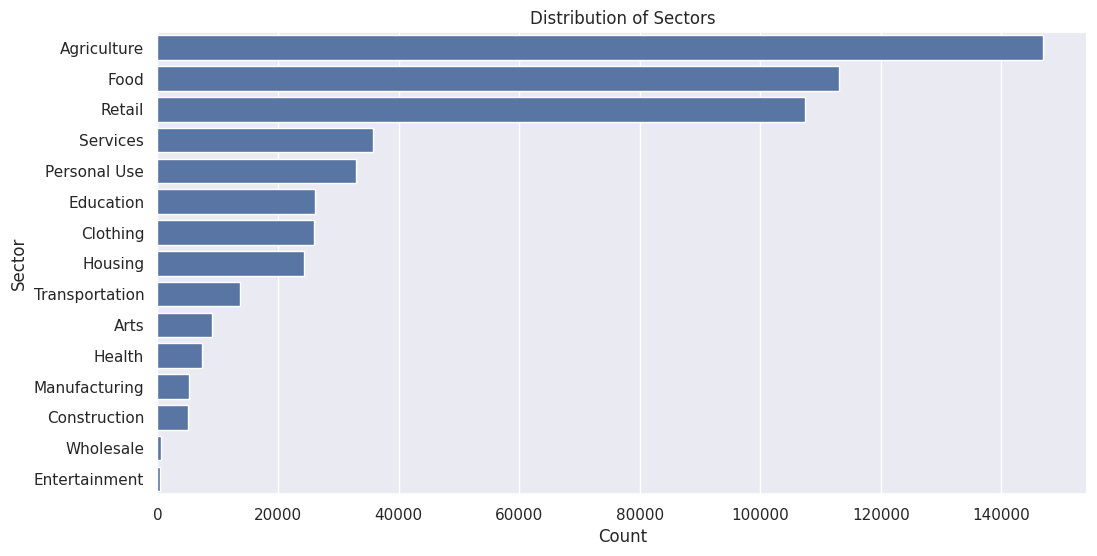

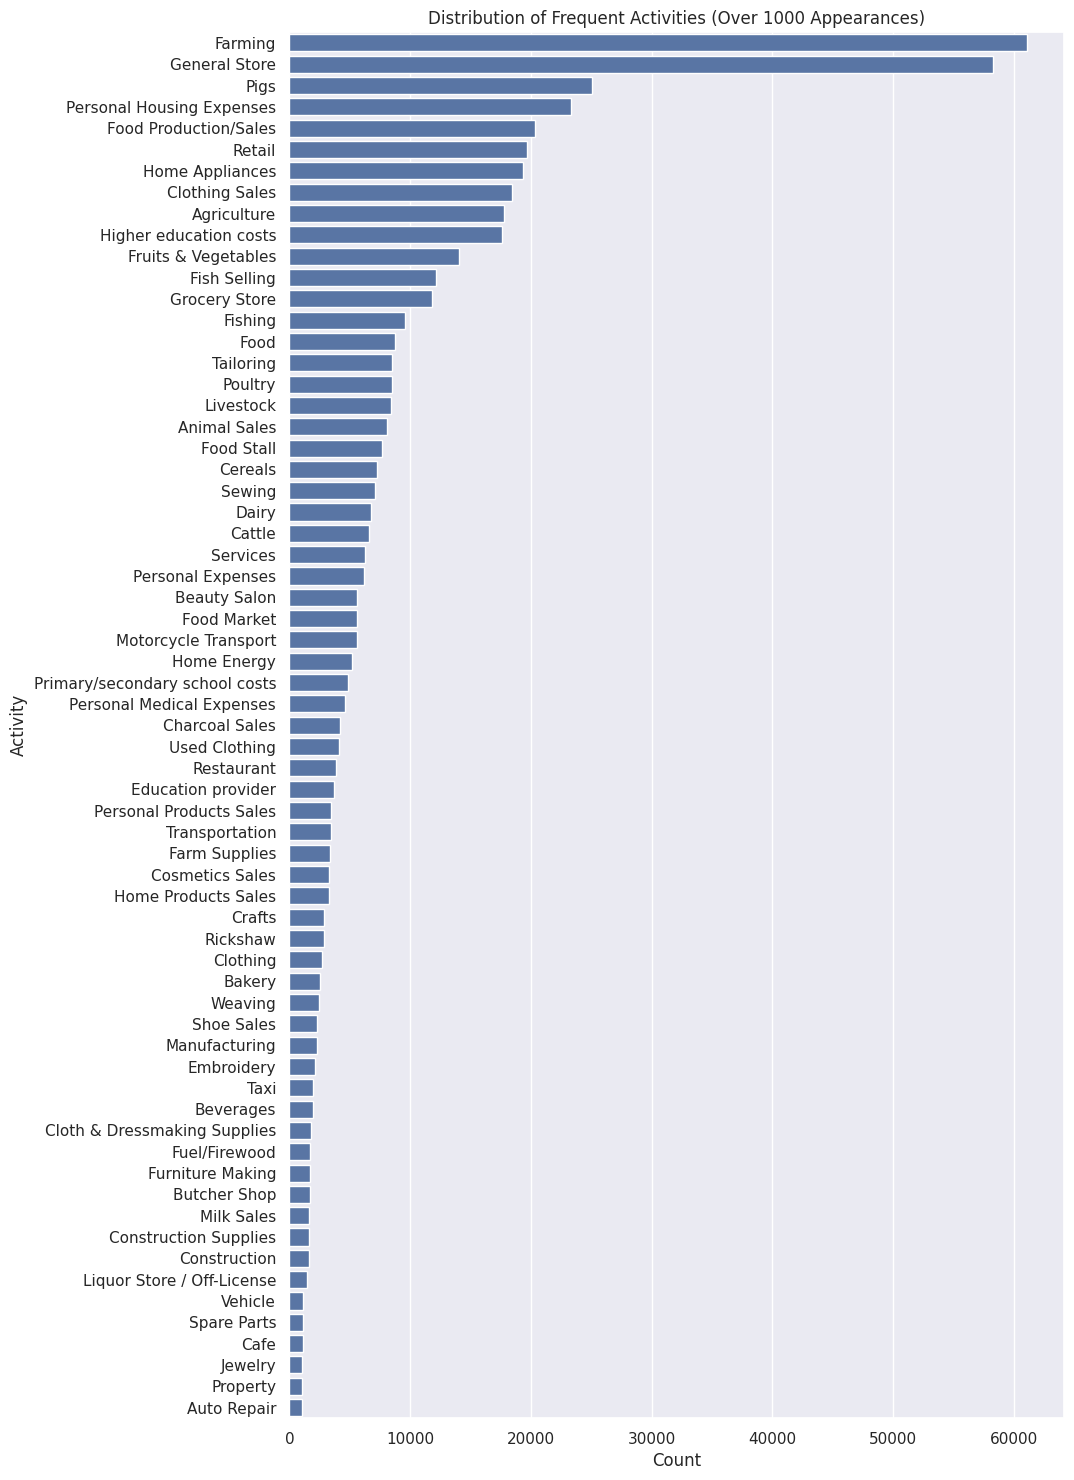

In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns

# Visualize unique sectors
plt.figure(figsize=(12, 6))
sns.countplot(y='sector', data=final_df, order=final_df['sector'].value_counts().index)
plt.title('Distribution of Sectors')
plt.xlabel('Count')
plt.ylabel('Sector')
plt.show()
print()
# Activities with more than 1000 appearances
activity_counts = final_df['activity'].value_counts()
frequent_activities = activity_counts[activity_counts > 1000]

plt.figure(figsize=(10, 18))
sns.countplot(y='activity', data=final_df[final_df['activity'].isin(frequent_activities.index)], order=frequent_activities.index)
plt.title('Distribution of Frequent Activities (Over 1000 Appearances)')
plt.xlabel('Count')
plt.ylabel('Activity')
plt.show()


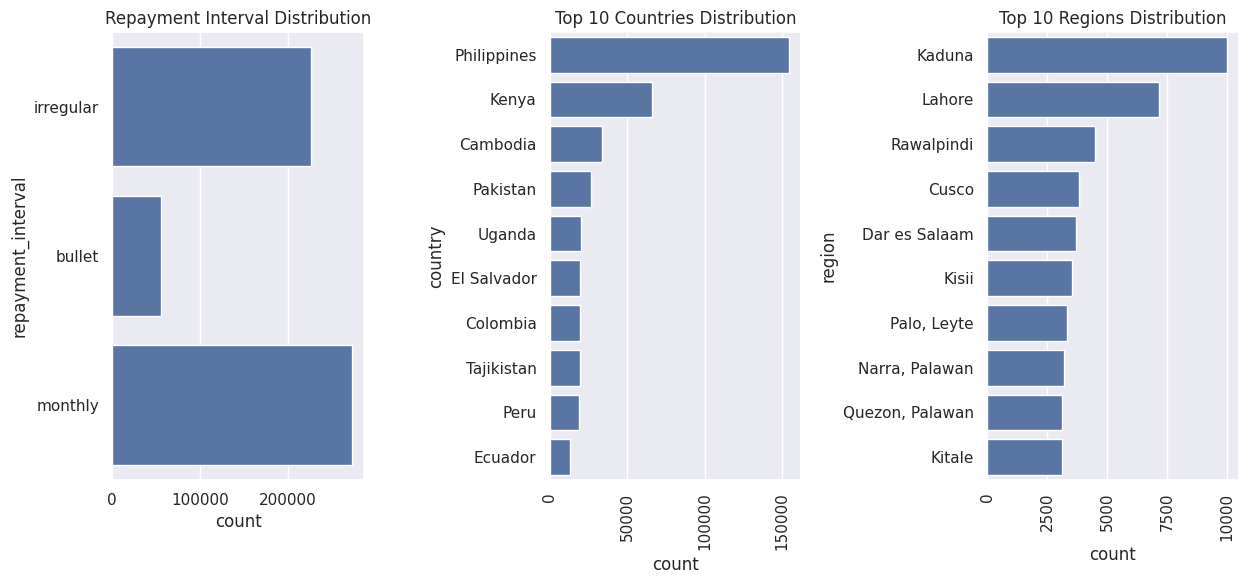

In [ ]:


plt.figure(figsize=(16, 6))


plt.subplot(1, 4, 2)
sns.countplot(y='repayment_interval', data=final_df)
plt.title('Repayment Interval Distribution')

plt.subplot(1, 4, 3)
sns.countplot(y='country', data=final_df, order=final_df['country'].value_counts().index[:10]) # Top 10 countries
plt.title('Top 10 Countries Distribution')
plt.xticks(rotation=90)


plt.subplot(1, 4, 4)
sns.countplot(y='region', data=final_df, order=final_df['region'].value_counts().index[:10])  # Top 10 regions
plt.title('Top 10 Regions Distribution')
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()


In [ ]:
# Find the number of unique rows for each column
unique_counts = final_df.nunique()

# Display the unique counts
print("Number of unique values for each column:\n")
print(unique_counts)

Number of unique values for each column:

funded_amount                                              455
loan_amount                                                454
activity                                                   163
sector                                                      15
use                                                     337747
country                                                     73
region                                                    5295
partner_id                                                 304
term_in_months                                             144
lender_count                                               441
borrower_genders                                          9064
repayment_interval                                           3
Region                                                      18
GDP: Gross domestic product (million current US$)           73
GDP growth rate (annual %, const. 2005 prices)              50
GDP per capit

In [ ]:
# Standardize the 'borrower_genders' column
def standardize_gender(gender_string):
    if isinstance(gender_string, str):
        genders = gender_string.lower().split(', ')
        if genders[0] == 'female':
            return 'female'
        elif genders[0] == 'male':
            return 'male'
    return gender_string # Return original if not string or doesn't start with male/female

final_df['borrower_genders'] = final_df['borrower_genders'].apply(standardize_gender)

# Print the number of unique values in the 'borrower_genders' column
print("Number of unique values in 'borrower_genders' after standardization:", final_df['borrower_genders'].nunique())
print("\nUnique values for 'borrower_genders':\n", final_df['borrower_genders'].unique())

Number of unique values in 'borrower_genders' after standardization: 2

Unique values for 'borrower_genders':
 ['female' 'male']


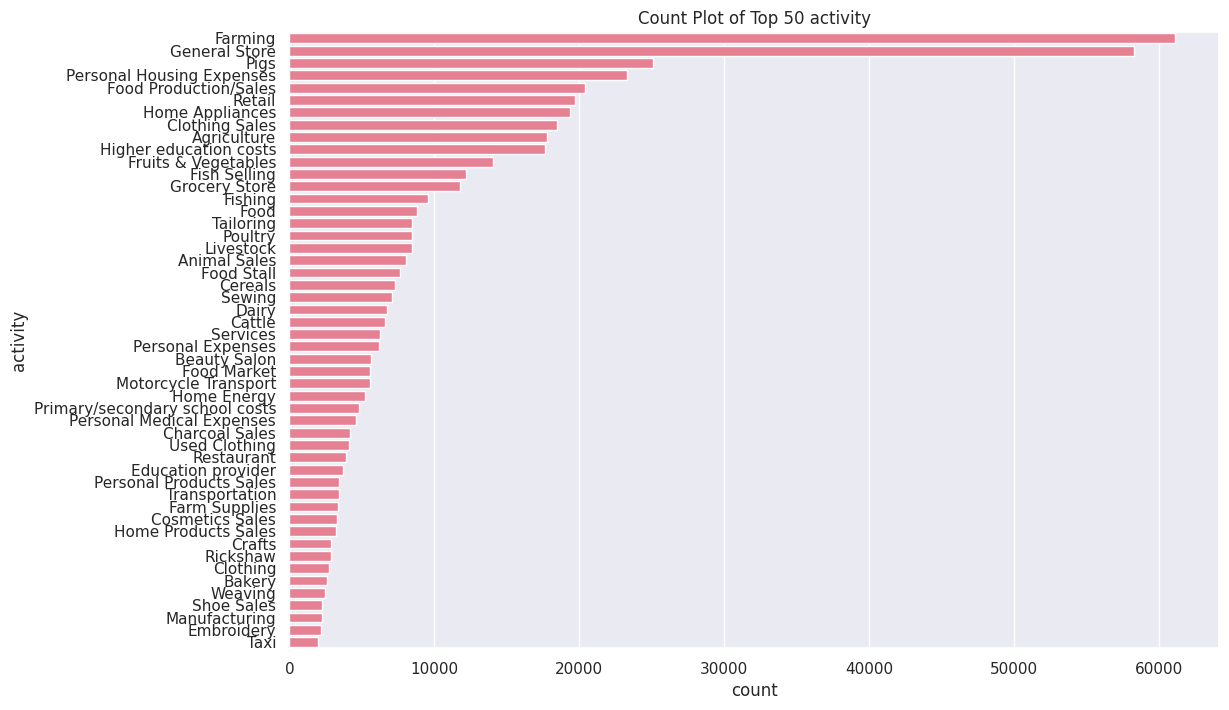

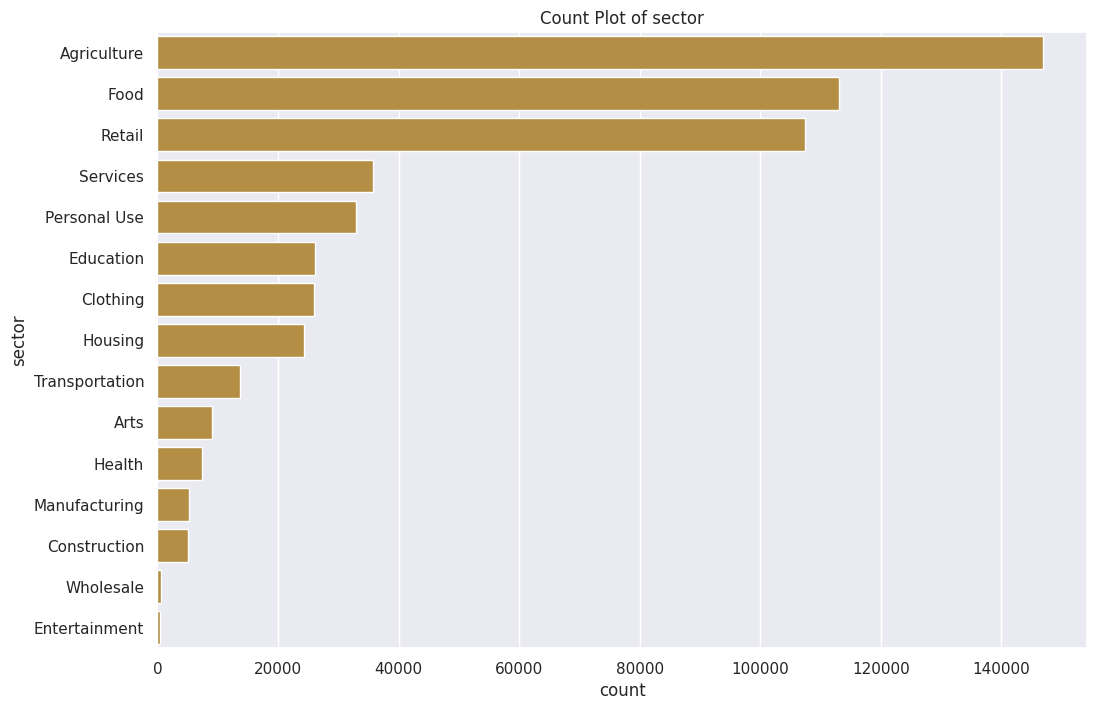

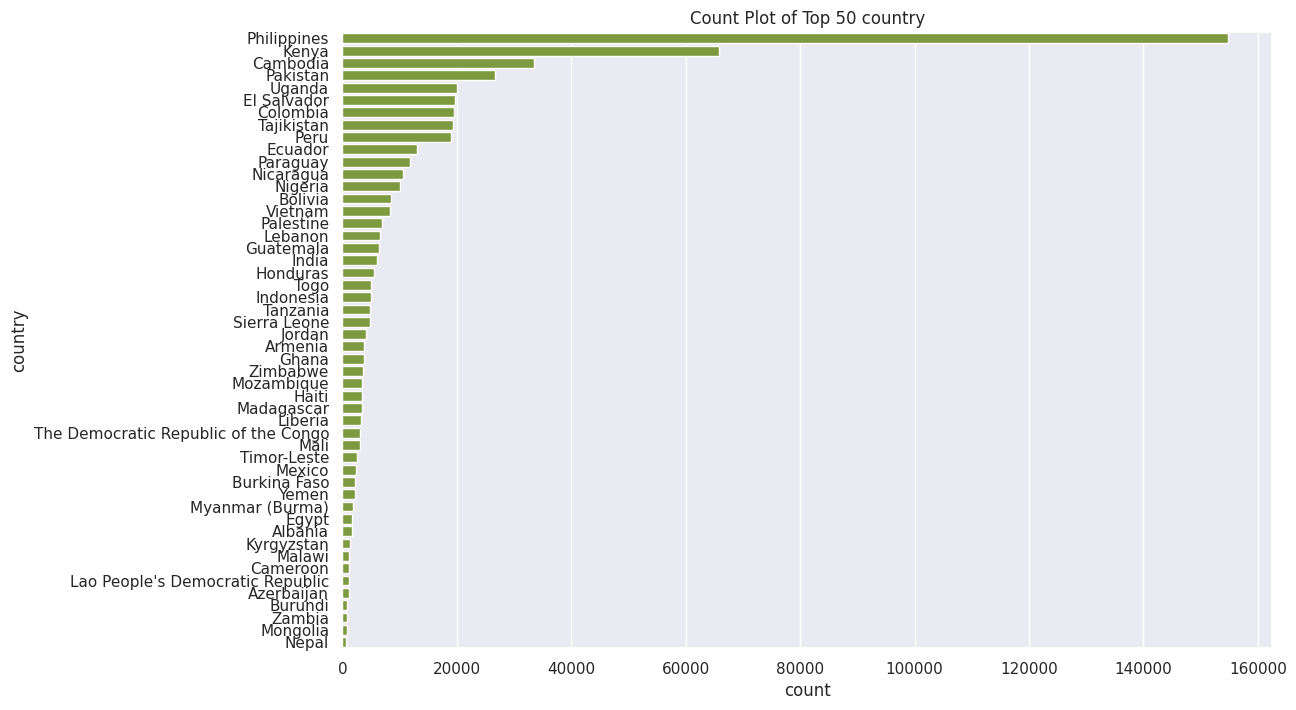

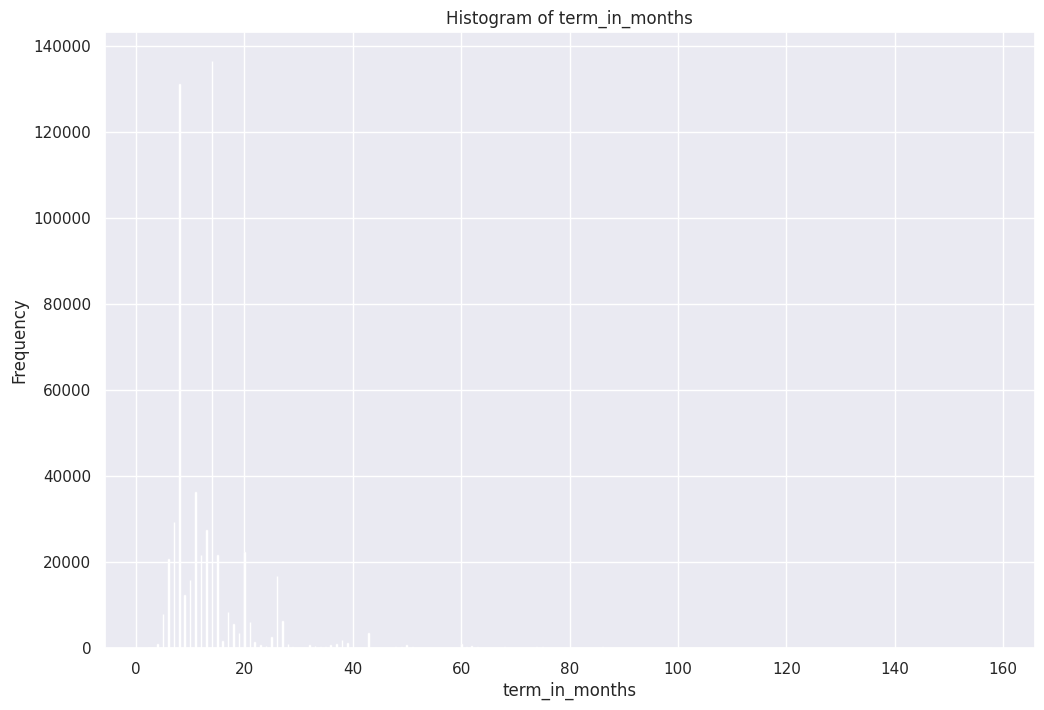

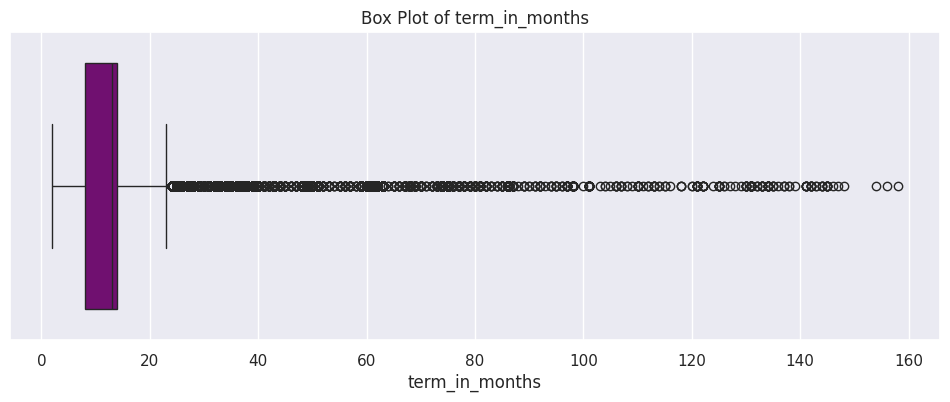

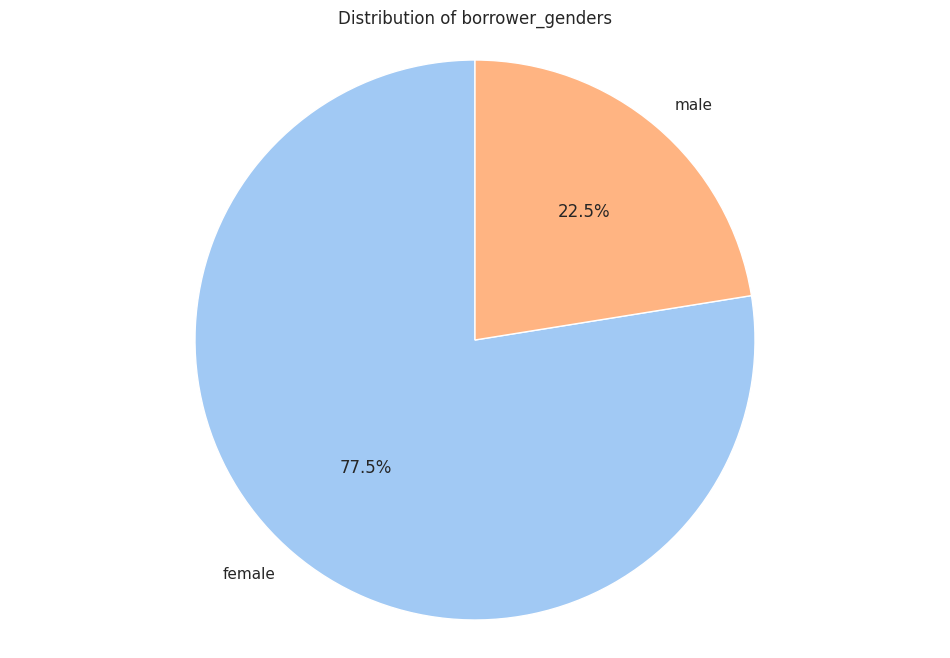

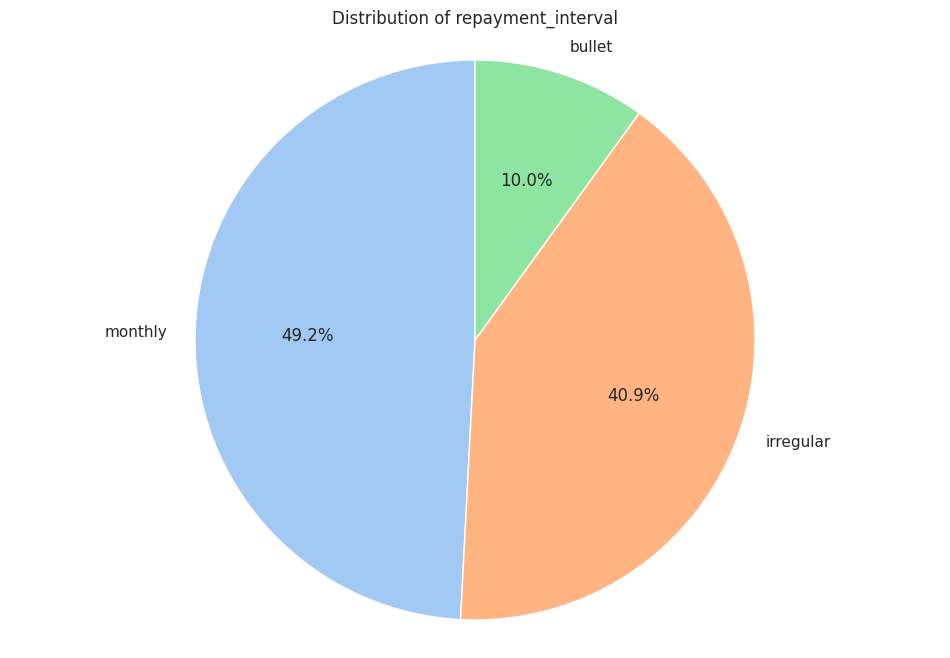

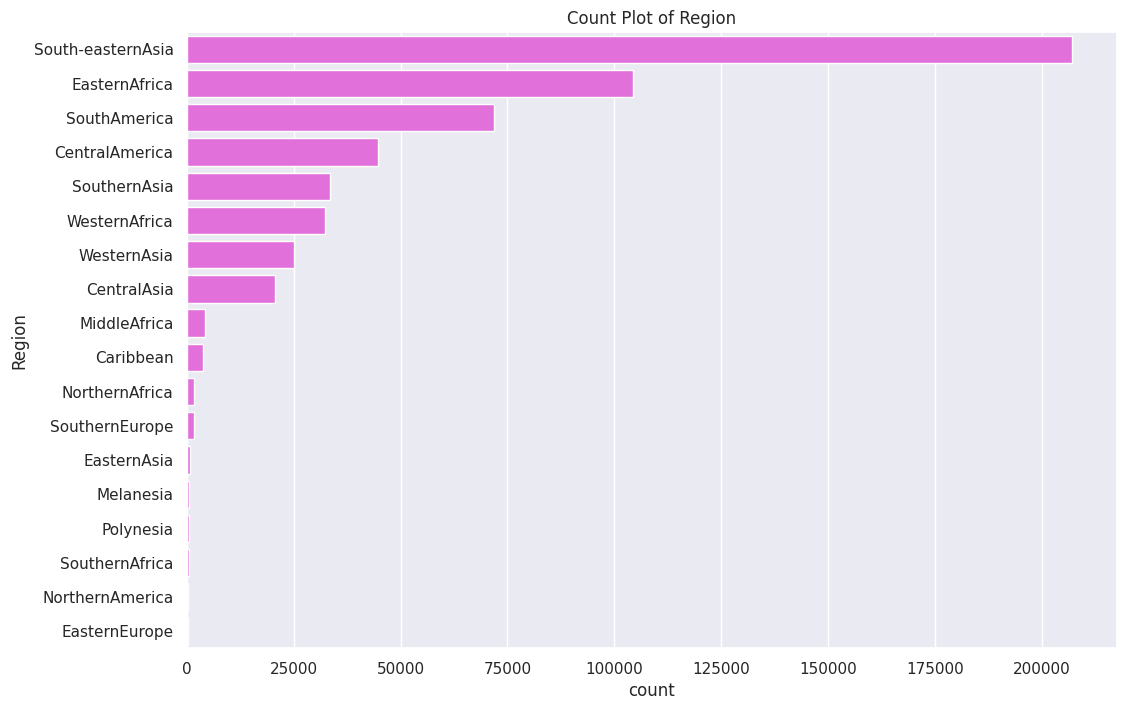

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

columns_to_visualize = ['activity', 'sector', 'country', 'term_in_months', 'borrower_genders', 'repayment_interval', 'Region']
palette = sns.color_palette("husl", len(columns_to_visualize))

for i, column in enumerate(columns_to_visualize):
    plt.figure(figsize=(12, 8))
    color = 'purple' if column == 'term_in_months' else palette[i]

    # Determine plot type based on data type and unique value count
    if final_df[column].dtype == 'object':
        if final_df[column].nunique() < 10: # Pie chart for categorical with very few unique values
            counts = final_df[column].value_counts()
            plt.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
            plt.title(f'Distribution of {column}')
            plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.

        elif final_df[column].nunique() < 50: # Count plot for categorical with few unique values
            sns.countplot(y=column, data=final_df, order=final_df[column].value_counts().index, color=color)
            plt.title(f'Count Plot of {column}')
        else: # Count plot for top N categorical values with many unique values
            top_n = 50
            top_values = final_df[column].value_counts().nlargest(top_n).index
            sns.countplot(y=column, data=final_df[final_df[column].isin(top_values)], order=top_values, color=color)
            plt.title(f'Count Plot of Top {top_n} {column}')

    elif final_df[column].dtype in ['int64', 'float64']:
        # Histogram for numerical columns
        plt.hist(final_df[column].dropna(), bins='auto', color=color)
        plt.title(f'Histogram of {column}')
        plt.xlabel(column)
        plt.ylabel('Frequency')

        # Box plot for numerical columns
        plt.figure(figsize=(12, 4))
        sns.boxplot(x=column, data=final_df, color=color)
        plt.title(f'Box Plot of {column}')
        plt.xlabel(column)

    plt.show()

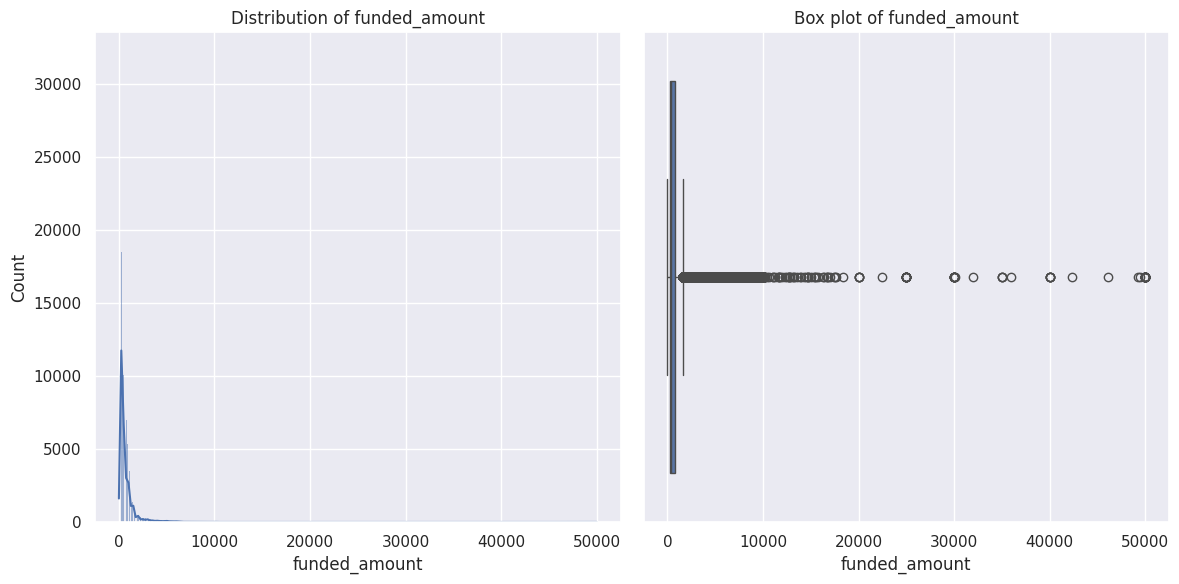

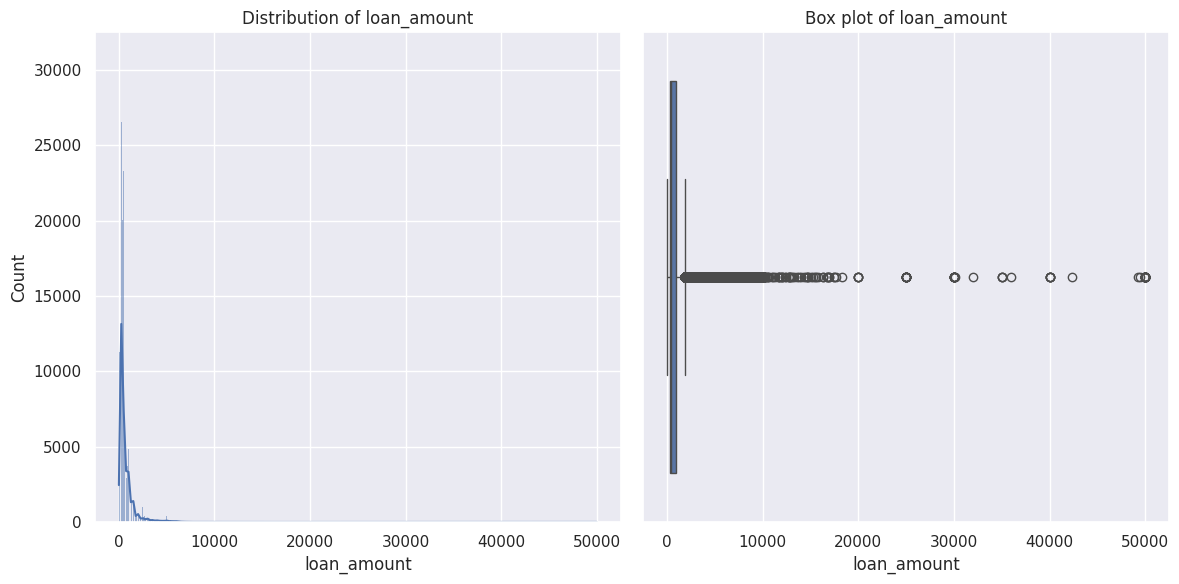

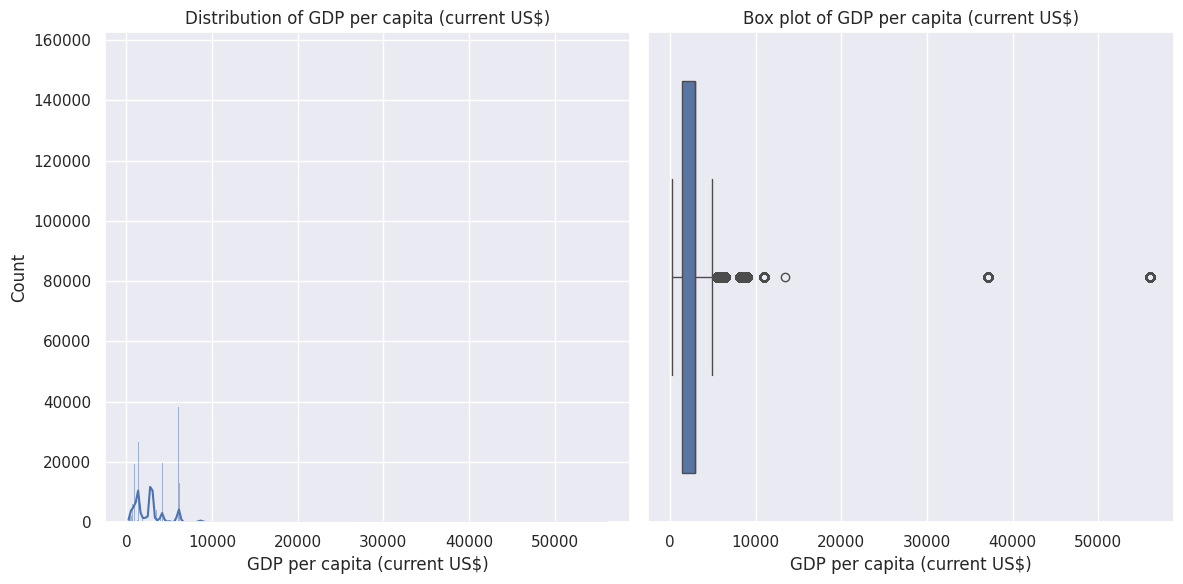

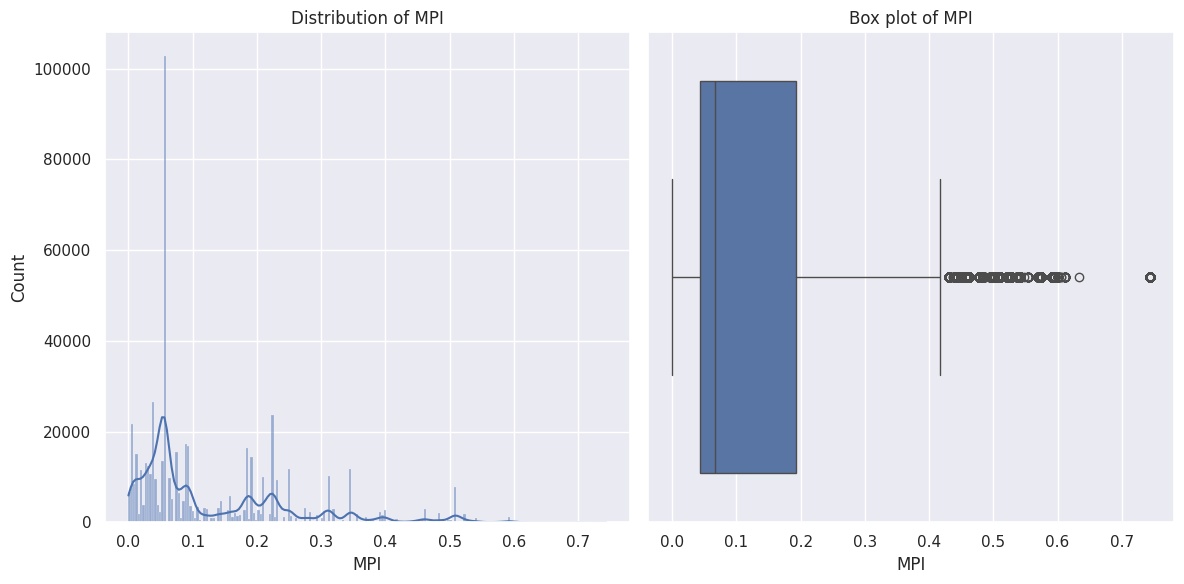

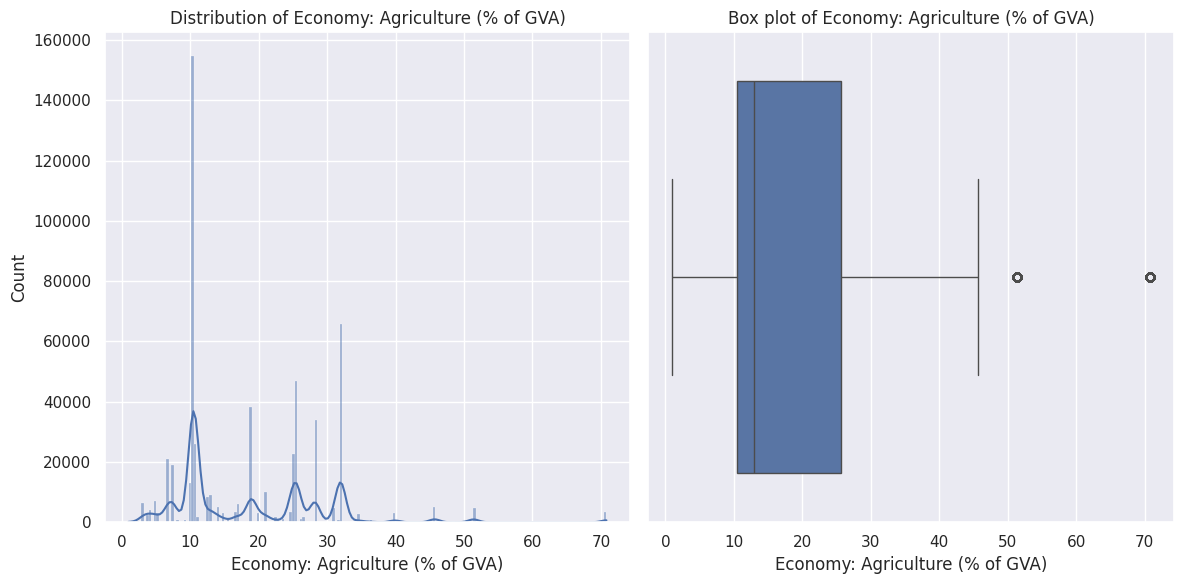

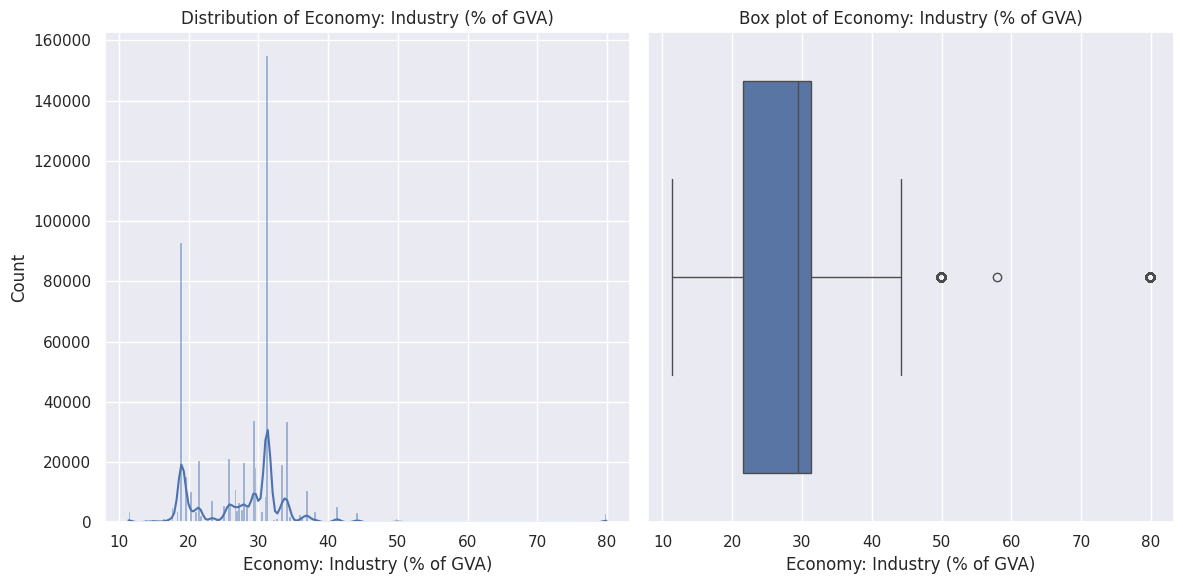

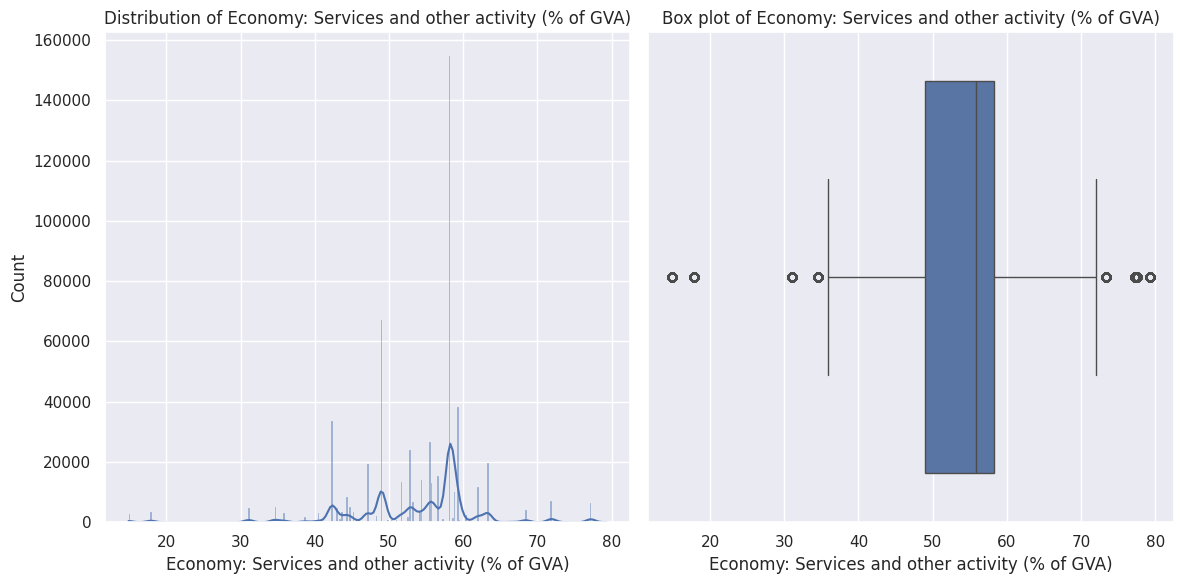

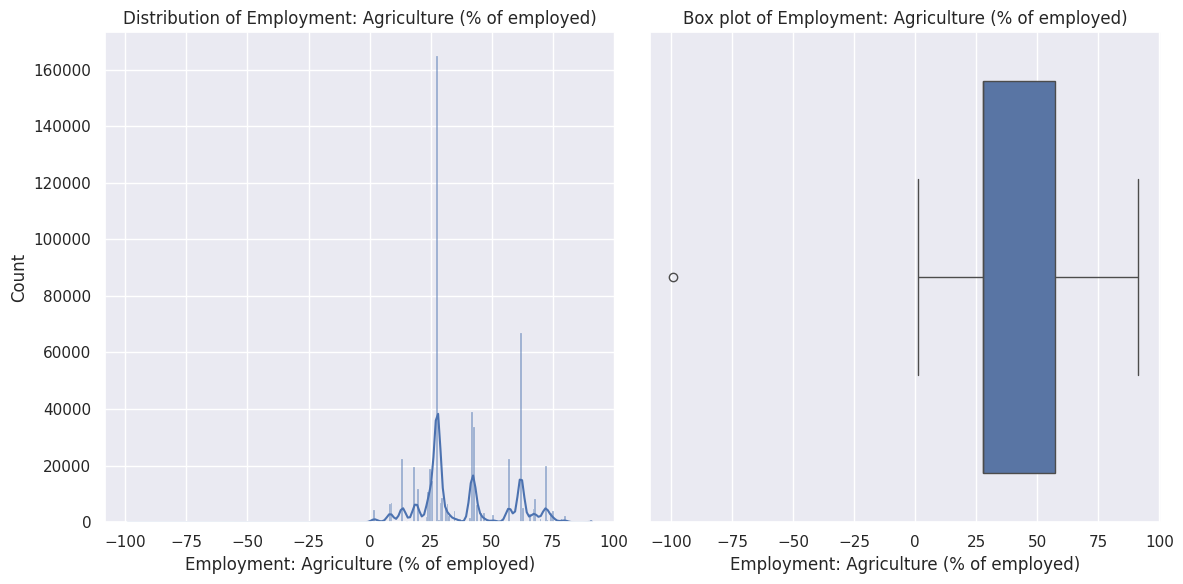

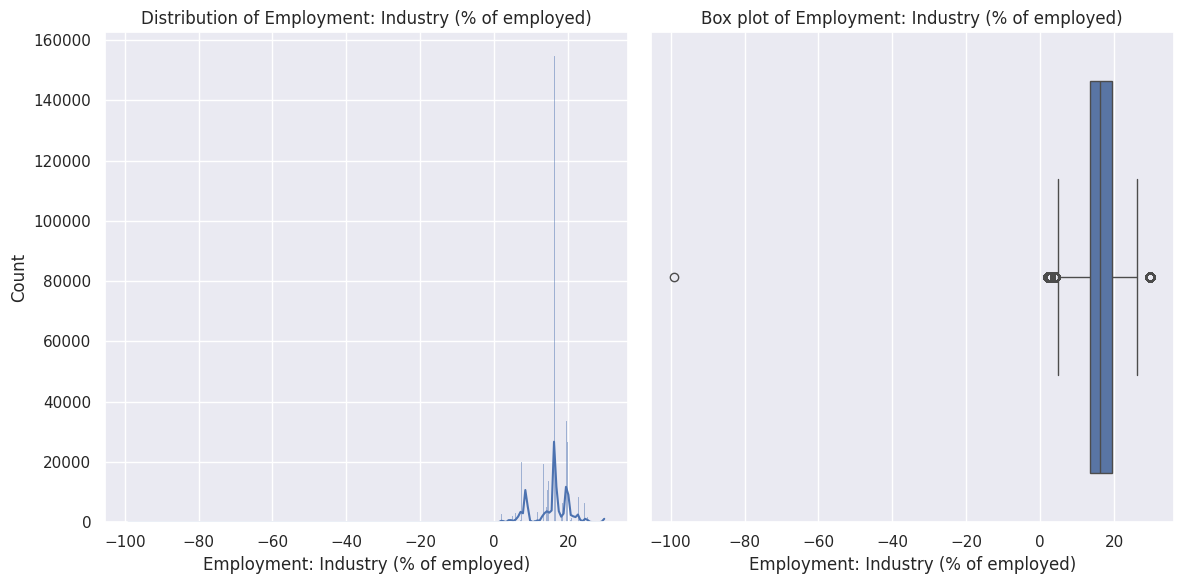

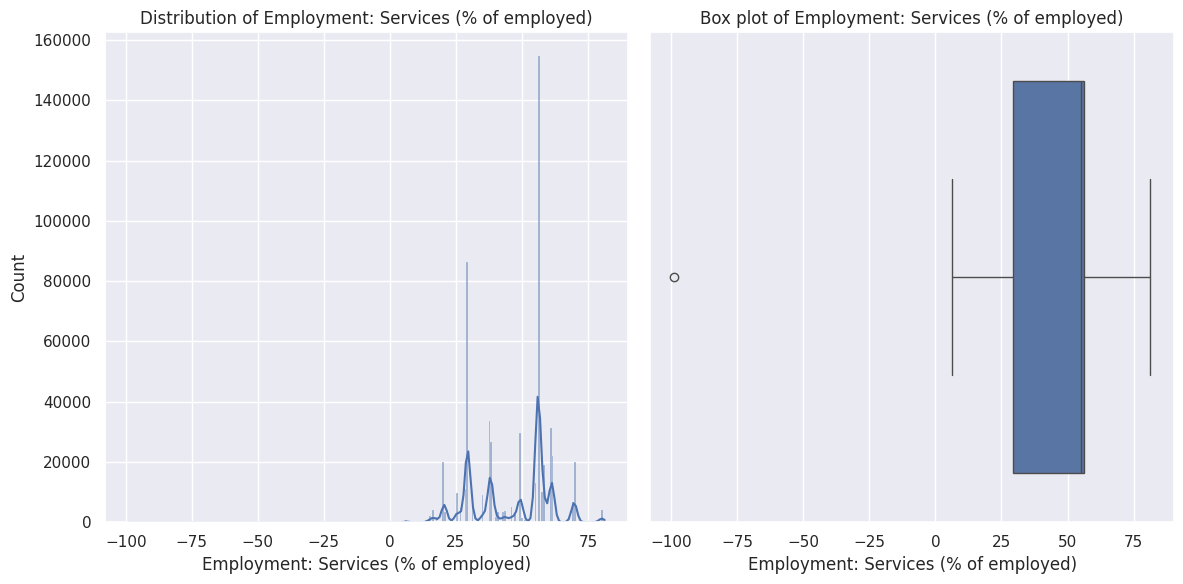

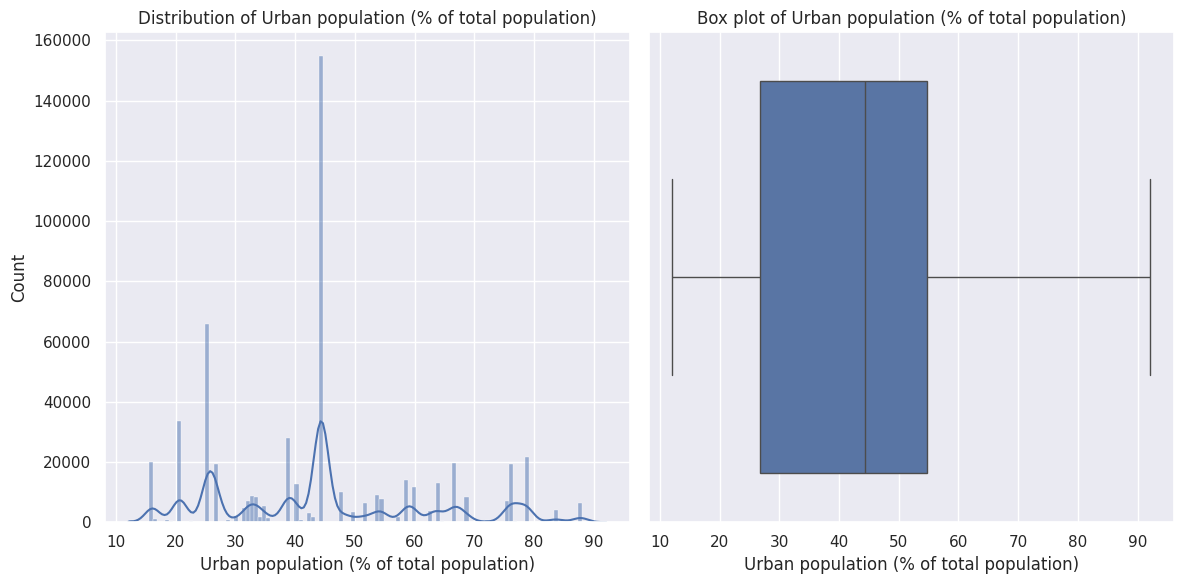

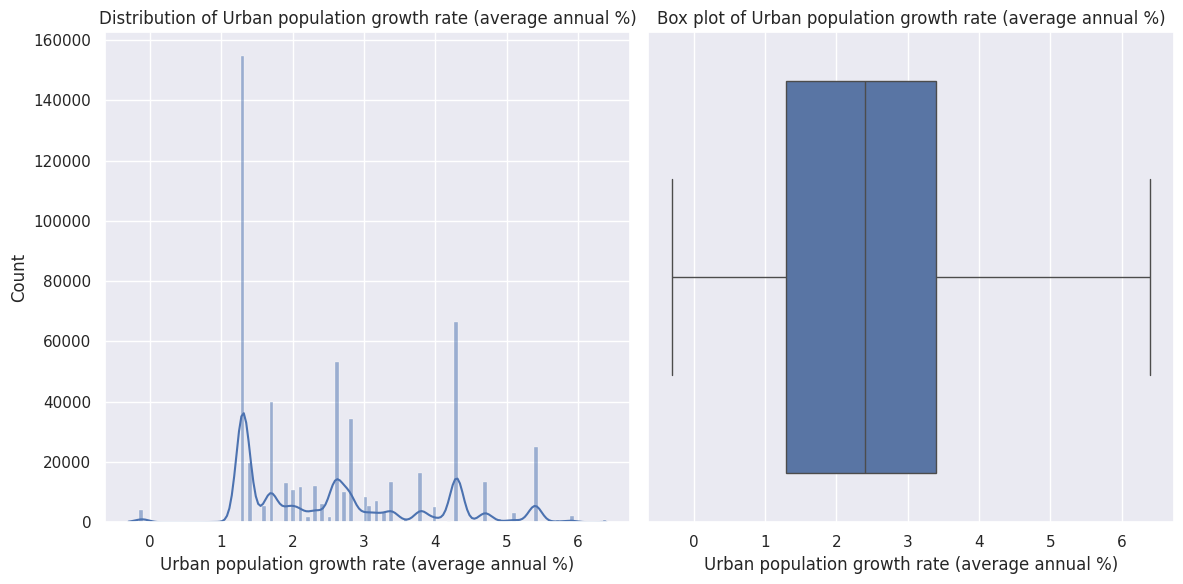

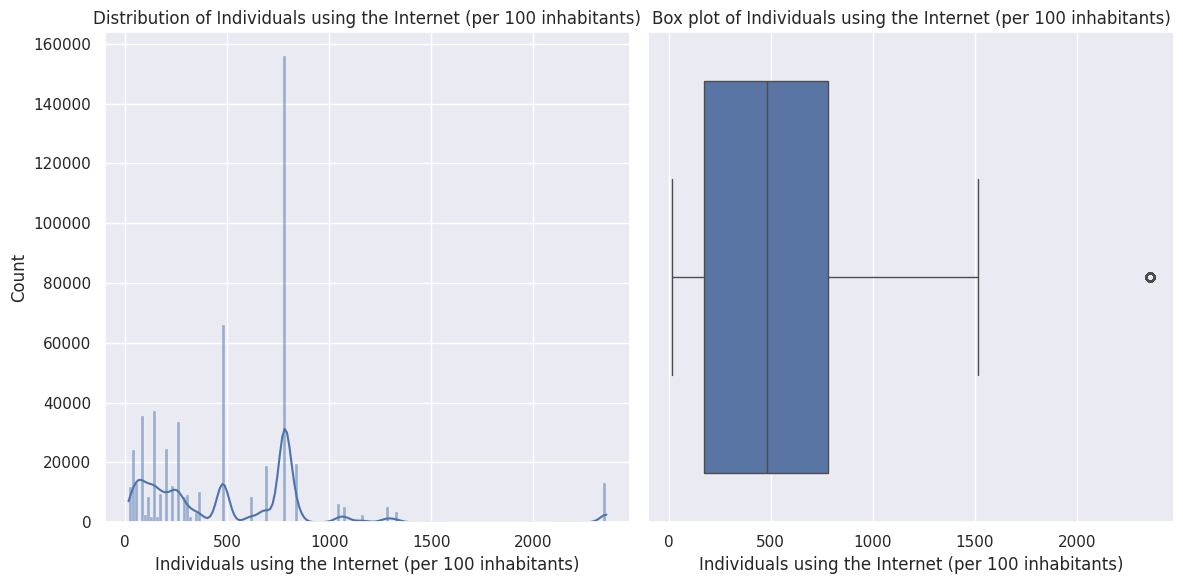

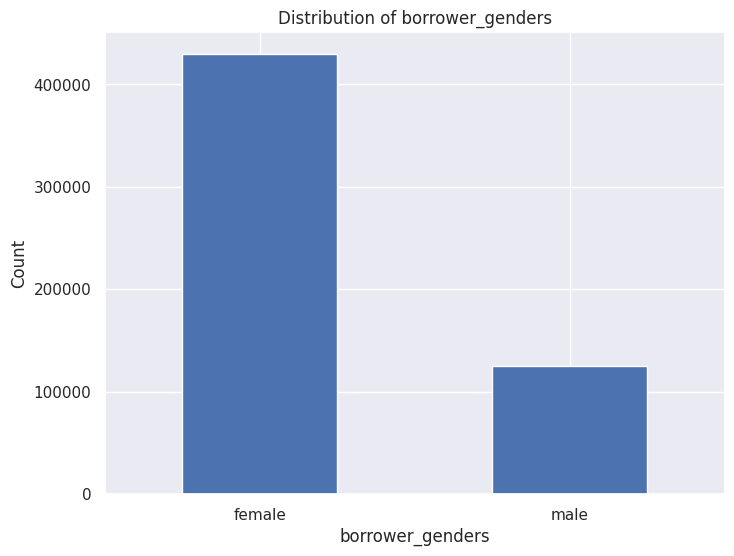

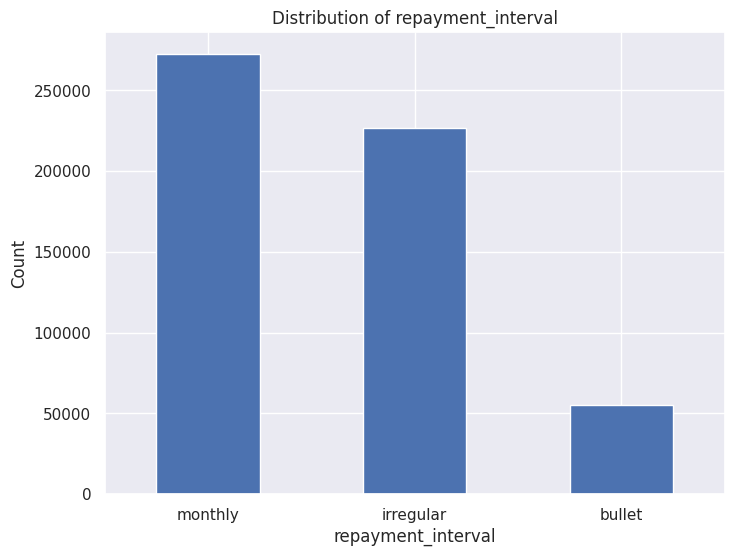

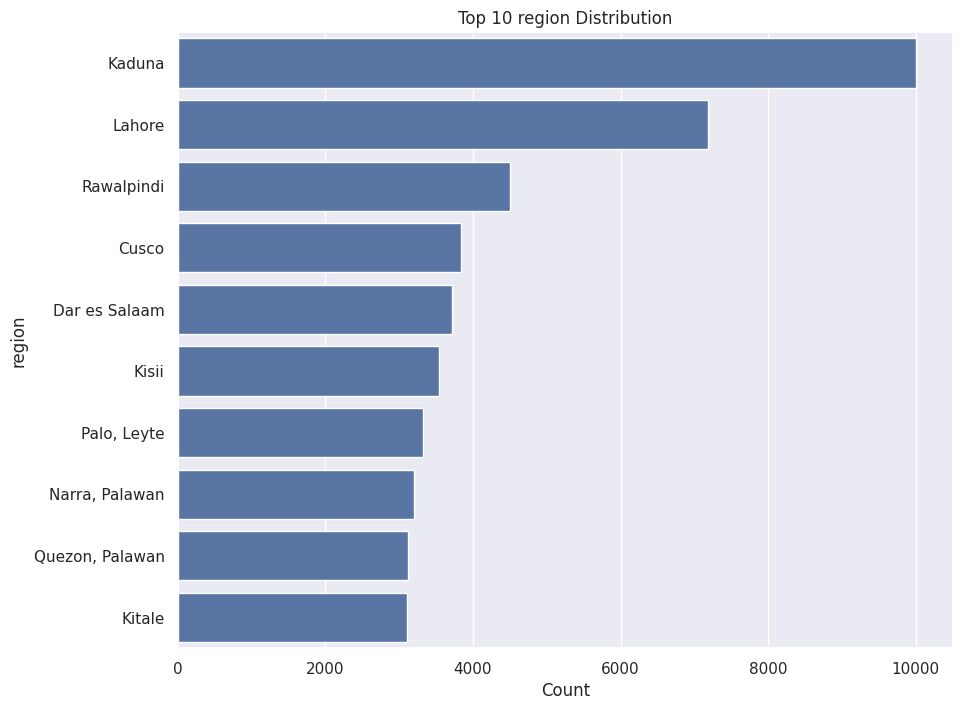

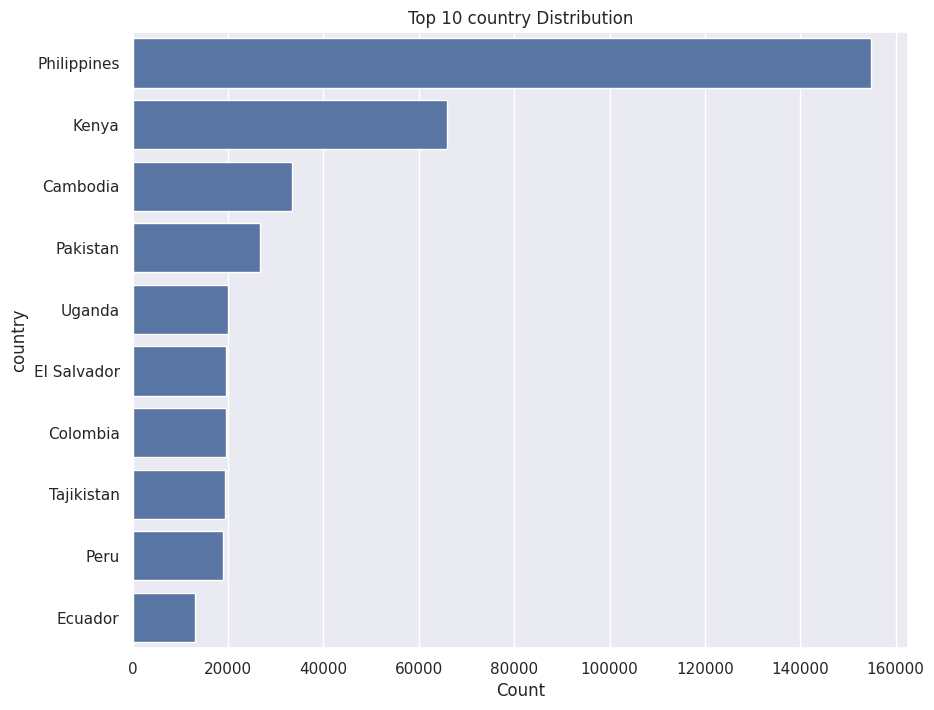

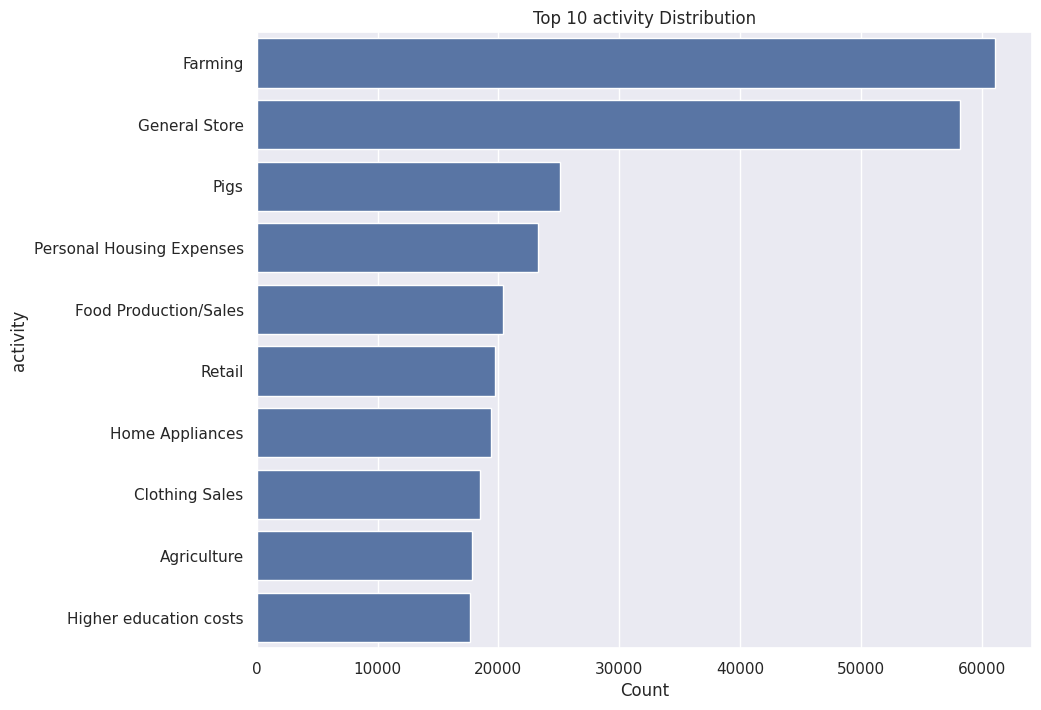

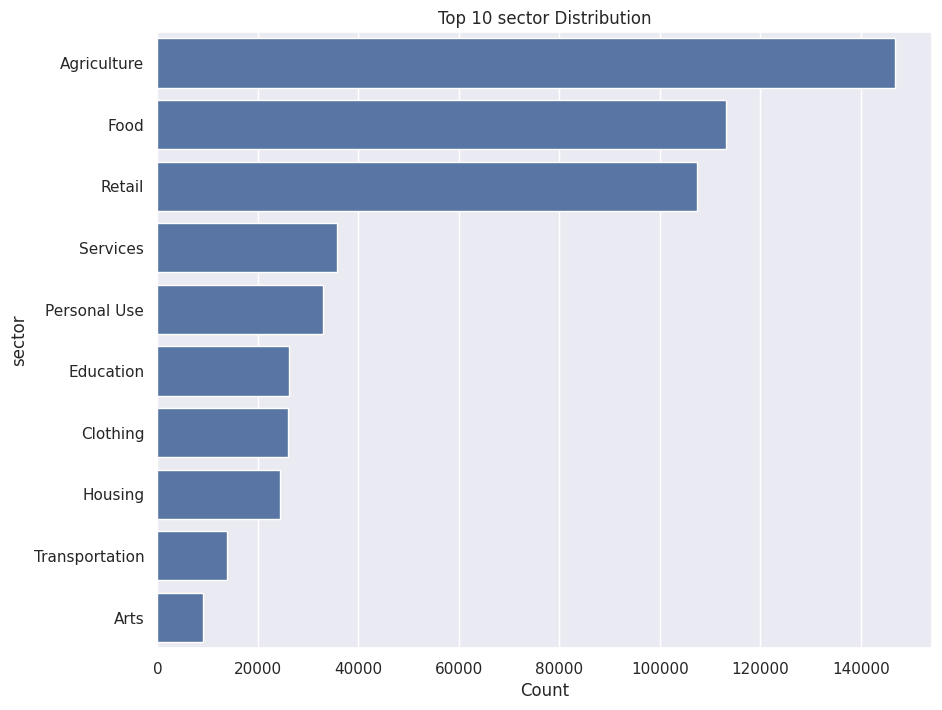

In [ ]:
numerical_cols_for_analysis = ['funded_amount', 'loan_amount', 'GDP per capita (current US$)', 'MPI', 'Economy: Agriculture (% of GVA)', 'Economy: Industry (% of GVA)', 'Economy: Services and other activity (% of GVA)', 'Employment: Agriculture (% of employed)', 'Employment: Industry (% of employed)', 'Employment: Services (% of employed)', 'Urban population (% of total population)', 'Urban population growth rate (average annual %)', 'Individuals using the Internet (per 100 inhabitants)']
categorical_cols_for_analysis = ['borrower_genders', 'repayment_interval']

# Histograms and Box plots for numerical columns
for col in numerical_cols_for_analysis:
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    sns.histplot(final_df[col].dropna(), kde=True)
    plt.title(f'Distribution of {col}')
    plt.subplot(1, 2, 2)
    sns.boxplot(x=final_df[col].dropna())
    plt.title(f'Box plot of {col}')
    plt.tight_layout()
    plt.show()

# Bar plots for categorical columns
for col in categorical_cols_for_analysis:
    plt.figure(figsize=(8, 6))
    final_df[col].value_counts().plot(kind='bar')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=0)
    plt.show()

# Bar plots for top N categorical columns with many unique values
categorical_cols_with_many_unique = ['region', 'country', 'activity', 'sector']
for col in categorical_cols_with_many_unique:
    plt.figure(figsize=(10, 8))
    top_n = 10
    top_values = final_df[col].value_counts().nlargest(top_n).index
    sns.countplot(y=col, data=final_df[final_df[col].isin(top_values)], order=top_values)
    plt.title(f'Top {top_n} {col} Distribution')
    plt.xlabel('Count')
    plt.ylabel(col)
    plt.show()

**Reasoning**:
Create pivot tables and grouped bar plots to explore the relationship between key columns like loan amount, MPI, country, and region.



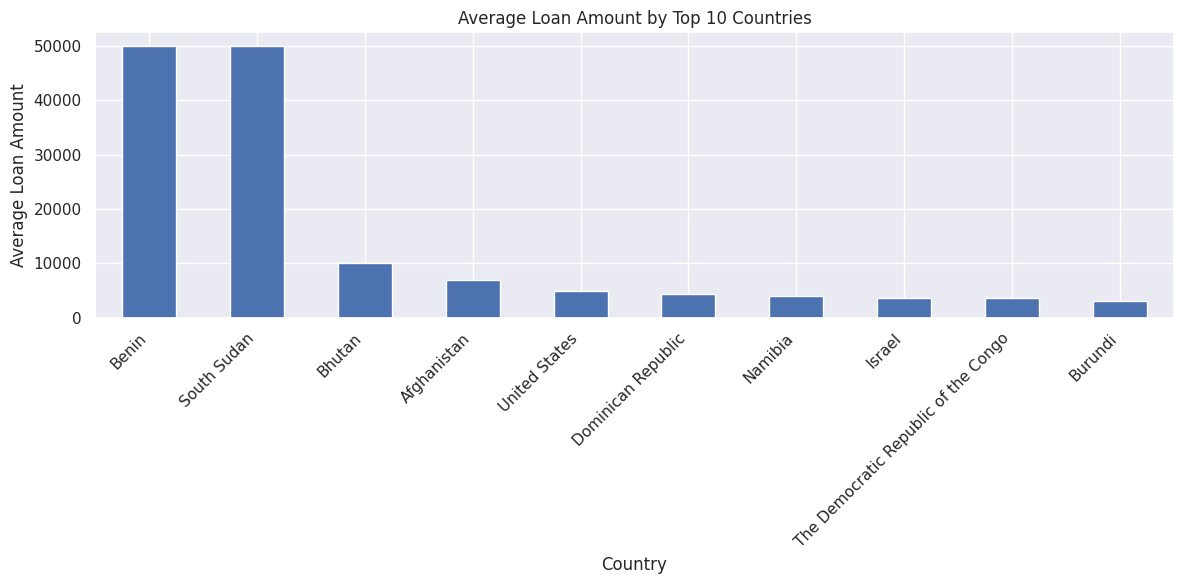

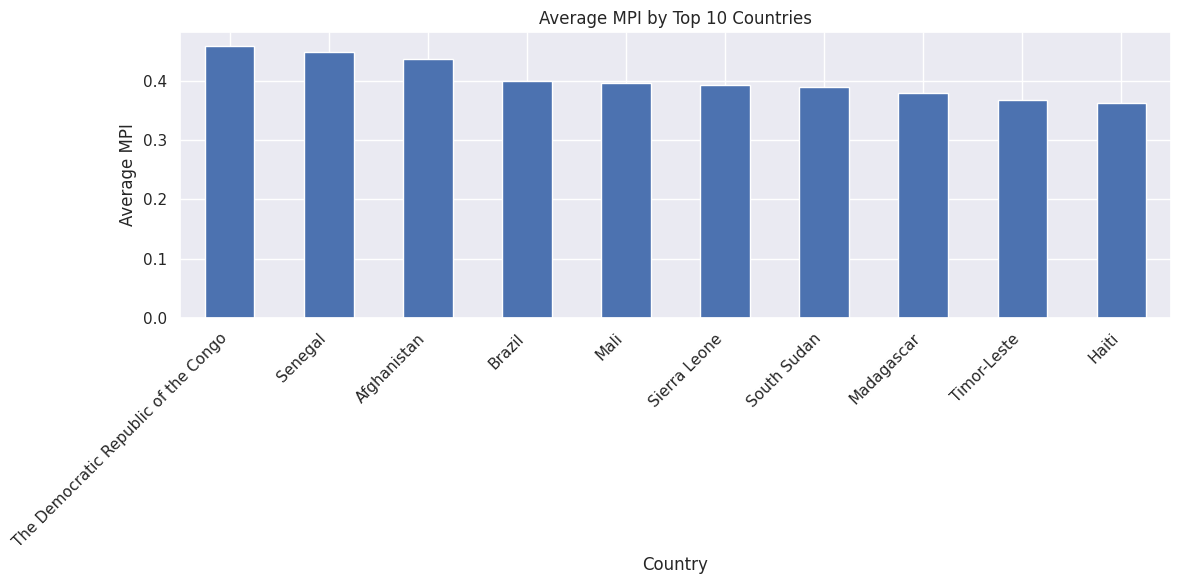

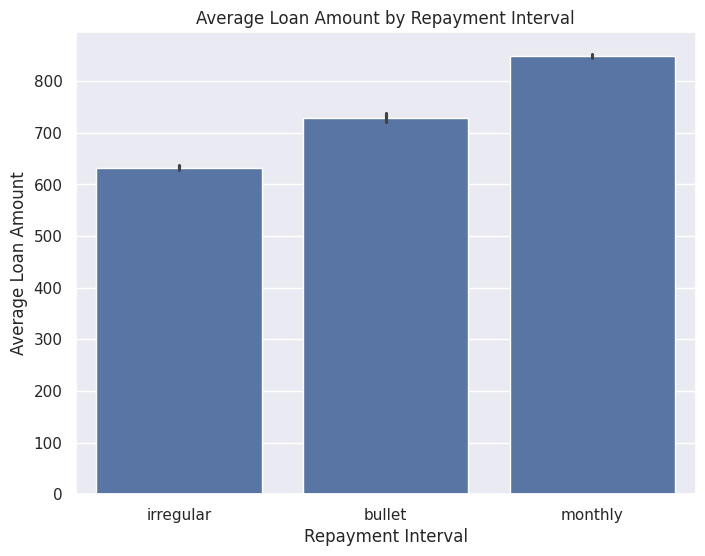

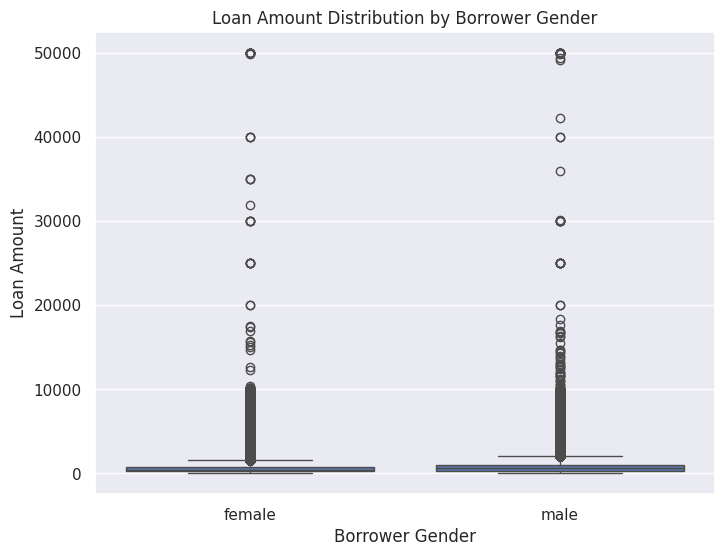

In [ ]:
# Average loan amount by country (top 10 countries)
plt.figure(figsize=(12, 6))
avg_loan_country = final_df.groupby('country')['loan_amount'].mean().nlargest(10)
avg_loan_country.plot(kind='bar')
plt.title('Average Loan Amount by Top 10 Countries')
plt.xlabel('Country')
plt.ylabel('Average Loan Amount')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Average MPI by country (top 10 countries with highest MPI)
plt.figure(figsize=(12, 6))
avg_mpi_country = final_df.groupby('country')['MPI'].mean().nlargest(10)
avg_mpi_country.plot(kind='bar')
plt.title('Average MPI by Top 10 Countries')
plt.xlabel('Country')
plt.ylabel('Average MPI')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Average loan amount by repayment interval
plt.figure(figsize=(8, 6))
sns.barplot(x='repayment_interval', y='loan_amount', data=final_df)
plt.title('Average Loan Amount by Repayment Interval')
plt.xlabel('Repayment Interval')
plt.ylabel('Average Loan Amount')
plt.show()

# Relationship between borrower gender and loan amount
plt.figure(figsize=(8, 6))
sns.boxplot(x='borrower_genders', y='loan_amount', data=final_df)
plt.title('Loan Amount Distribution by Borrower Gender')
plt.xlabel('Borrower Gender')
plt.ylabel('Loan Amount')
plt.show()